# Progetto della parte finale del corso di "Data Mining" da 12 CFU

## MODULE 0: Data Understanding & Preparation

* Exploratory Analysis using the raw dataset
* Distribution of Continuous and Categorical Variables using the raw dataset
* Data Cleaning and noise Elimination
* Feature Engineering
* Correlations between Continuous Variables using Pearson and Spearman techniques
* Correlations between Categorical Variables using Cramer's V technique
* More in depth data cleaning and preparation
* Feature Scaling: Continuous Variable Normalization (aka Standardization)
* Pre-Processing: One Hot Encode for Categorical Variables (not the ordinal ones ofc)
* Pre-Processing: Multi-Label Binarization for Multi_label (lists like) Categorical Variables

---

### Informazioni Generali

* **Corso:** Data Mining
* **Università:** Università di Pisa
* **Anno Accademico:** 2024/2025

### Autore

* **Studente:** Giuseppe Muschetta
* **Matricola:** 564026

### Dataset Utilizzato

* **Nome:** Extended IMDb Dataset (Tabulare)
* **Descrizione:** Dataset tabulare contenente circa 150,000 record con informazioni relative ai titoli cinematografici.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import time
from mlxtend.frequent_patterns import fpgrowth
from pygments.lexer import include

# --- IMPOSTAZIONI GLOBALI PER I GRAFICI ---
# Avere uno stile coerente è fondamentale per un report professionale.
# Abbiamo scelto un tema scuro che è piacevole alla vista.
plt.style.use("dark_background")
sns.set_theme(
    style="darkgrid",
    context="notebook",
    palette="icefire",
    font="sans-serif",
    font_scale=1.1
)
plt.rcParams.update({
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold', 'axes.edgecolor': 'white',
    'axes.labelcolor': 'white', 'xtick.color': 'lightgray', 'ytick.color': 'lightgray',
    'text.color': 'white', 'grid.color': '#333333', 'grid.linestyle': '--',
    'grid.alpha': 0.3, 'figure.facecolor': '#111111', 'axes.facecolor': '#111111',
    'savefig.facecolor': '#111111'
})
print("✅ Impostazioni grafiche caricate.")


# --- CREAZIONE DIRECTORY PER I PLOT ---
# Organizziamo il nostro lavoro salvando tutti i grafici in una cartella dedicata.
plots_dir = 'plots_data_understanding_tabular/'
os.makedirs(plots_dir, exist_ok=True)
print(f"✅ Directory per i grafici '{plots_dir}' pronta.")


# --- CARICAMENTO DEL DATASET ---
# Carichiamo i dati di training e test. Lavoreremo principalmente sul training set
# per l'estrazione dei pattern, usando il test set solo alla fine per la valutazione.
dataset_dir = 'Dataset/'
dataset_name = 'imdb.csv'
try:
    data = pd.read_csv(os.path.join(dataset_dir, dataset_name))
    print(f"✅ Dataset di training caricato: {data.shape[0]} righe, {data.shape[1]} colonne.")
except FileNotFoundError as e:
    print(f"❌ Errore: File non trovato. Controlla il percorso '{dataset_dir + dataset_name}'. Dettagli: {e}")
    exit(1)


✅ Impostazioni grafiche caricate.
✅ Directory per i grafici 'plots_data_understanding_tabular/' pronta.
✅ Dataset di training caricato: 149531 righe, 32 colonne.


In [2]:
data

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,worstRating,bestRating,totalImages,...,genres,castNumber,companiesNumber,averageRating,regions,externalLinks,writerCredits,directorsCredits,soundMixes,quotesTotal
0,Carmencita,"(5, 6]",1894,\N,1,0,2089,1,10,2,...,"Documentary,Short",1,3,5.7,"['\\N', 'DE', 'US', 'HU', 'GR', 'RU', 'UA', 'JP']",9,0,1,['silent'],0
1,Un bon bock,"(5, 6]",1892,\N,12,0,183,1,10,2,...,"Animation,Short",0,0,5.4,"['\\N', 'HU', 'DE', 'FR', 'RO', 'RU', 'JP']",3,0,1,['silent'],0
2,Chinese Opium Den,"(4, 5]",1894,\N,1,0,195,1,10,1,...,Short,0,1,5.0,"['\\N', 'US', 'DE', 'PT', 'HU', 'RU']",4,0,1,['silent'],0
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,\N,1,1,2237,1,10,3,...,"Documentary,Short",1,6,5.4,"['\\N', 'UA', 'JP', 'HU', 'US', 'DE', 'RU']",6,0,1,['silent'],0
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,\N,1,0,13115,1,10,12,...,"Documentary,Short",6,5,7.4,"['\\N', 'HU', 'DE', 'TR', 'FI', 'FR', 'IT', 'E...",21,0,2,['silent'],0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149526,Nuestra película,"(6, 7]",1993,\N,96,0,11,1,10,0,...,Documentary,0,2,7.0,"['\\N', 'CO']",1,1,1,[],0
149527,Eco,"(6, 7]",2019,\N,14,0,15,1,10,4,...,"Drama,Short",6,3,6.4,"['\\N', 'ES']",5,1,1,[],0
149528,Women Take Center Stage,"(5, 6]",2019,\N,\N,0,12,1,10,2,...,Reality-TV,1,0,5.6,['\\N'],0,0,0,[],0
149529,Horrid Henry and the Christening Crisis,"(7, 8]",2011,\N,10,0,9,1,10,1,...,"Adventure,Animation,Comedy",7,0,7.1,['\\N'],0,3,1,[],0


### Analisi Esplorativa del Dataset Grezzo

In [2]:
data.head(10)

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,worstRating,bestRating,totalImages,...,genres,castNumber,companiesNumber,averageRating,regions,externalLinks,writerCredits,directorsCredits,soundMixes,quotesTotal
0,Carmencita,"(5, 6]",1894,\N,1,0,2089,1,10,2,...,"Documentary,Short",1,3,5.7,"['\\N', 'DE', 'US', 'HU', 'GR', 'RU', 'UA', 'JP']",9,0,1,['silent'],0
1,Un bon bock,"(5, 6]",1892,\N,12,0,183,1,10,2,...,"Animation,Short",0,0,5.4,"['\\N', 'HU', 'DE', 'FR', 'RO', 'RU', 'JP']",3,0,1,['silent'],0
2,Chinese Opium Den,"(4, 5]",1894,\N,1,0,195,1,10,1,...,Short,0,1,5.0,"['\\N', 'US', 'DE', 'PT', 'HU', 'RU']",4,0,1,['silent'],0
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,\N,1,1,2237,1,10,3,...,"Documentary,Short",1,6,5.4,"['\\N', 'UA', 'JP', 'HU', 'US', 'DE', 'RU']",6,0,1,['silent'],0
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,\N,1,0,13115,1,10,12,...,"Documentary,Short",6,5,7.4,"['\\N', 'HU', 'DE', 'TR', 'FI', 'FR', 'IT', 'E...",21,0,2,['silent'],0
5,Autour d'une cabine,"(6, 7]",1894,\N,2,0,1220,1,10,15,...,"Animation,Short",0,0,6.1,"['\\N', 'ES', 'US', 'FR', 'HU', 'RU', 'UA']",3,0,1,['silent'],0
6,Place des Cordeliers à Lyon,"(5, 6]",1895,\N,1,0,1235,1,10,5,...,"Documentary,Short",0,2,5.6,"['\\N', 'GB', 'US', 'XWW', 'FR', 'ES', 'UA', '...",2,0,1,['silent'],0
7,La voltige,"(5, 6]",1895,\N,1,0,1104,1,10,5,...,"Comedy,Documentary,Short",0,2,5.5,"['\\N', 'RU', 'UA', 'GB', 'US', 'XWW', 'BR', '...",2,0,1,['silent'],0
8,L'arroseur,"(5, 6]",1896,\N,1,0,84,1,10,1,...,"Comedy,Short",0,1,5.5,"['\\N', 'FR', 'XWW', 'US', 'RU']",2,0,1,['silent'],0
9,The Ball Game,"(4, 5]",1898,\N,1,0,220,1,10,1,...,"Documentary,Short,Sport",3,2,4.2,"['\\N', 'US']",2,0,1,['silent'],0


In [3]:
data.shape

(149531, 32)

In [4]:
data.info(verbose=True, memory_usage='deep', show_counts=True)
# countryOfOrigin ha 39987 valori nulli


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149531 entries, 0 to 149530
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   originalTitle                149531 non-null  object 
 1   rating                       149531 non-null  object 
 2   startYear                    149531 non-null  int64  
 3   endYear                      149531 non-null  object 
 4   runtimeMinutes               149531 non-null  object 
 5   awardWins                    149531 non-null  int64  
 6   numVotes                     149531 non-null  int64  
 7   worstRating                  149531 non-null  int64  
 8   bestRating                   149531 non-null  int64  
 9   totalImages                  149531 non-null  int64  
 10  totalVideos                  149531 non-null  int64  
 11  totalCredits                 149531 non-null  int64  
 12  criticReviewsTotal           149531 non-null  int64  
 13 

In [5]:
data.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
originalTitle,149531,133101,Episode #1.1,532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,149531,10,"(7, 8]",48555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
startYear,149531.0,NaN,NaN,NaN,1994.939852,24.890965,1878.0,1981.0,1999.0,2015.0,2024.0
endYear,149531,79,\N,143897,NaN,NaN,NaN,NaN,NaN,NaN,NaN
runtimeMinutes,149531,377,\N,40195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
awardWins,149531.0,NaN,NaN,NaN,0.308558,2.912763,0.0,0.0,0.0,0.0,446.0
numVotes,149531.0,NaN,NaN,NaN,1085.134962,19999.73252,5.0,12.0,28.0,107.0,2947931.0
worstRating,149531.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
bestRating,149531.0,NaN,NaN,NaN,10.0,0.0,10.0,10.0,10.0,10.0,10.0
totalImages,149531.0,NaN,NaN,NaN,9.531856,101.653836,0.0,1.0,1.0,4.0,20586.0


In [6]:
print(data['isRatable'].unique())
# avendo zero varianza (un solo valore nella colonna) come anche bestRating, worstRating

[ True]


In [7]:
# Per adesso isAdult la convertiamo al suo tipo originale e cioè booleano
data['isAdult'] = data['isAdult'].astype(bool)

In [8]:
# --- IDENTIFICAZIONE E GESTIONE DEI DUPLICATI ---

print("--- Controllo dei record duplicati ---")

# 1. Identifichiamo il numero di righe duplicate
#    subset=None controlla la duplicazione basandosi su TUTTE le colonne.
num_duplicates = data.duplicated(subset=None).sum()

print(f"Numero di righe duplicate trovate: {num_duplicates}")

if num_duplicates > 0:
    # 2. Mostriamo un campione dei duplicati per ispezione (opzionale)
    #    keep=False mostra TUTTE le occorrenze di una riga duplicata.
    print("\nCampione di righe duplicate:")
    display(data[data.duplicated(subset=None, keep=False)].head())

    # 3. Proponiamo l'eliminazione
    print(f"\nSi procederà con l'eliminazione di {num_duplicates} righe duplicate.")
    initial_rows = len(data)

    # Rimuoviamo i duplicati, mantenendo la prima occorrenza (keep='first')
    data.drop_duplicates(subset=None, keep='first', inplace=True)

    final_rows = len(data)
    print("✅ Duplicati rimossi con successo.")
    print(f"   Numero di righe iniziale: {initial_rows}")
    print(f"   Numero di righe finale: {final_rows}")
else:
    print("✅ Ottimo! Nessun duplicato trovato nel dataset.")

--- Controllo dei record duplicati ---
Numero di righe duplicate trovate: 10

Campione di righe duplicate:


,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,worstRating,bestRating,totalImages,...,genres,castNumber,companiesNumber,averageRating,regions,externalLinks,writerCredits,directorsCredits,soundMixes,quotesTotal
61835,Paradise Found: Creating the Director's Cut,"(7, 8]",2006,\N,9,0,20,1,10,0,...,Short,6,2,7.4,"['\\N', 'US']",0,0,1,['dolby_digital'],0
61836,Paradise Found: Creating the Director's Cut,"(7, 8]",2006,\N,9,0,20,1,10,0,...,Short,6,2,7.4,"['\\N', 'US']",0,0,1,['dolby_digital'],0
81846,Bryan Cranston/Julia Garner/Surfaces,"(7, 8]",2020,\N,41,0,8,1,10,0,...,"Comedy,Music,Talk-Show",6,0,8.0,"['\\N', 'US']",39,14,2,['stereo'],0
81847,Bryan Cranston/Julia Garner/Surfaces,"(7, 8]",2020,\N,41,0,8,1,10,0,...,"Comedy,Music,Talk-Show",6,0,8.0,"['\\N', 'US']",39,14,2,['stereo'],0
83076,Masters of the Universe,"(7, 8]",2020,\N,92,0,18,1,10,2,...,Comedy,2,0,7.5,"['\\N', 'DE']",0,2,0,[],0



Si procederà con l'eliminazione di 10 righe duplicate.
✅ Duplicati rimossi con successo.
   Numero di righe iniziale: 149531
   Numero di righe finale: 149521


#### GESTIONE VARIABILI CATEGORICHE multi-label

In [9]:
# %% md
#### 2.1 Pulizia: Conversione Specializzata di Tutte le Colonne Complesse
# %%
# OBIETTIVO:
# Convertire TUTTE le colonne complesse nel formato corretto (lista di stringhe),
# includendo 'soundMixes' nel processo, utilizzando funzioni specifiche per
# ogni tipo di formato di partenza.
#
# LOGICA:
# - Per 'genres' (stringhe con virgole): si usa una funzione che splitta per virgola.
# - Per 'countryOfOrigin', 'regions' e 'soundMixes' (stringhe formato lista):
#   si usa la funzione con ast.literal_eval per interpretare la struttura della lista.

import ast

# --- Funzione 1: Per stringhe separate da virgola (formato di 'genres') ---
def parse_comma_separated_string(value):
    """Converte una stringa come 'Comedy,Drama' in una lista ['Comedy', 'Drama']."""
    if isinstance(value, str) and value != '\\N':
        return [item.strip() for item in value.split(',') if item.strip()]
    return []

# --- Funzione 2: Per stringhe formato lista (es. "['US']") ---
def parse_list_string(value):
    """Converte una stringa come "['US']" in una lista ['US']."""
    if isinstance(value, str) and value.startswith('[') and value.endswith(']'):
        try:
            # Pulisce il placeholder '\\N' prima della conversione
            cleaned_value = value.replace("'\\\\N'", "''")
            py_list = ast.literal_eval(cleaned_value)
            # Rimuove le stringhe vuote risultanti
            return [item for item in py_list if item]
        except (ValueError, SyntaxError):
            return []
    return []


print("--- Inizio conversione specializzata delle colonne ---")

# --- Applichiamo la funzione giusta alla colonna giusta ---

# 1. Processiamo 'genres' con la sua funzione specifica
data['genres'] = data['genres'].apply(parse_comma_separated_string)
print("Colonna 'genres' processata con successo.")

# 2. Processiamo le altre colonne, INCLUDENDO soundMixes
other_list_cols = ['countryOfOrigin', 'regions', 'soundMixes']
for col in other_list_cols:
    data[col] = data[col].apply(parse_list_string)
    print(f"Colonna '{col}' processata con successo.")

print("--- Conversione completata. ---")

# VERIFICA: Controlliamo che ora le colonne contengano vere liste
print(f"\nEsempio da 'genres': {data['genres'].iloc[1] if len(data) > 1 else 'N/A'}")
print(f"Esempio da 'soundMixes': {data['soundMixes'].iloc[0] if len(data) > 0 else 'N/A'}")

--- Inizio conversione specializzata delle colonne ---
Colonna 'genres' processata con successo.
Colonna 'countryOfOrigin' processata con successo.
Colonna 'regions' processata con successo.
Colonna 'soundMixes' processata con successo.
--- Conversione completata. ---

Esempio da 'genres': ['Animation', 'Short']
Esempio da 'soundMixes': ['silent']


In [10]:
# %% md
#### Verifica Programmatica del Tipo di Dato
# %%
# OBIETTIVO:
# Controllare in modo inequivocabile il tipo di dato Python degli elementi
# nelle colonne che abbiamo processato. Questo test ci darà la certezza
# matematica che la nostra pulizia ha funzionato come previsto.

# Lista delle colonne che dovrebbero contenere liste
cols_to_verify = ['genres', 'countryOfOrigin', 'regions', 'soundMixes']

print("--- Verifica del tipo di dato reale per ogni colonna ---")

for col in cols_to_verify:
    try:
        # Seleziona il primo elemento non nullo della colonna
        first_valid_item = data[col].dropna().iloc[0]
        # Stampa il suo tipo
        item_type = type(first_valid_item)
        print(f"Colonna '{col}': Il primo elemento valido è di tipo -> {item_type}")

        if item_type is list:
            print("   (CONFERMATO: È una vera lista Python)")
        else:
            print("   (ATTENZIONE: NON è una lista Python)")

    except IndexError:
        print(f"Colonna '{col}': Non è stato possibile trovare un elemento valido (forse è tutta vuota).")
    except Exception as e:
        print(f"Errore nell'analisi della colonna '{col}': {e}")

--- Verifica del tipo di dato reale per ogni colonna ---
Colonna 'genres': Il primo elemento valido è di tipo -> <class 'list'>
   (CONFERMATO: È una vera lista Python)
Colonna 'countryOfOrigin': Il primo elemento valido è di tipo -> <class 'list'>
   (CONFERMATO: È una vera lista Python)
Colonna 'regions': Il primo elemento valido è di tipo -> <class 'list'>
   (CONFERMATO: È una vera lista Python)
Colonna 'soundMixes': Il primo elemento valido è di tipo -> <class 'list'>
   (CONFERMATO: È una vera lista Python)


In [11]:
data

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,worstRating,bestRating,totalImages,...,genres,castNumber,companiesNumber,averageRating,regions,externalLinks,writerCredits,directorsCredits,soundMixes,quotesTotal
0,Carmencita,"(5, 6]",1894,\N,1,0,2089,1,10,2,...,"[Documentary, Short]",1,3,5.7,"[DE, US, HU, GR, RU, UA, JP]",9,0,1,[silent],0
1,Un bon bock,"(5, 6]",1892,\N,12,0,183,1,10,2,...,"[Animation, Short]",0,0,5.4,"[HU, DE, FR, RO, RU, JP]",3,0,1,[silent],0
2,Chinese Opium Den,"(4, 5]",1894,\N,1,0,195,1,10,1,...,[Short],0,1,5.0,"[US, DE, PT, HU, RU]",4,0,1,[silent],0
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,\N,1,1,2237,1,10,3,...,"[Documentary, Short]",1,6,5.4,"[UA, JP, HU, US, DE, RU]",6,0,1,[silent],0
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,\N,1,0,13115,1,10,12,...,"[Documentary, Short]",6,5,7.4,"[HU, DE, TR, FI, FR, IT, ES, SK, PL, GB, XWW, ...",21,0,2,[silent],0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149526,Nuestra película,"(6, 7]",1993,\N,96,0,11,1,10,0,...,[Documentary],0,2,7.0,[CO],1,1,1,[],0
149527,Eco,"(6, 7]",2019,\N,14,0,15,1,10,4,...,"[Drama, Short]",6,3,6.4,[ES],5,1,1,[],0
149528,Women Take Center Stage,"(5, 6]",2019,\N,\N,0,12,1,10,2,...,[Reality-TV],1,0,5.6,[],0,0,0,[],0
149529,Horrid Henry and the Christening Crisis,"(7, 8]",2011,\N,10,0,9,1,10,1,...,"[Adventure, Animation, Comedy]",7,0,7.1,[],0,3,1,[],0


### Distribuzione delle variabili categoriche ESPLOSE

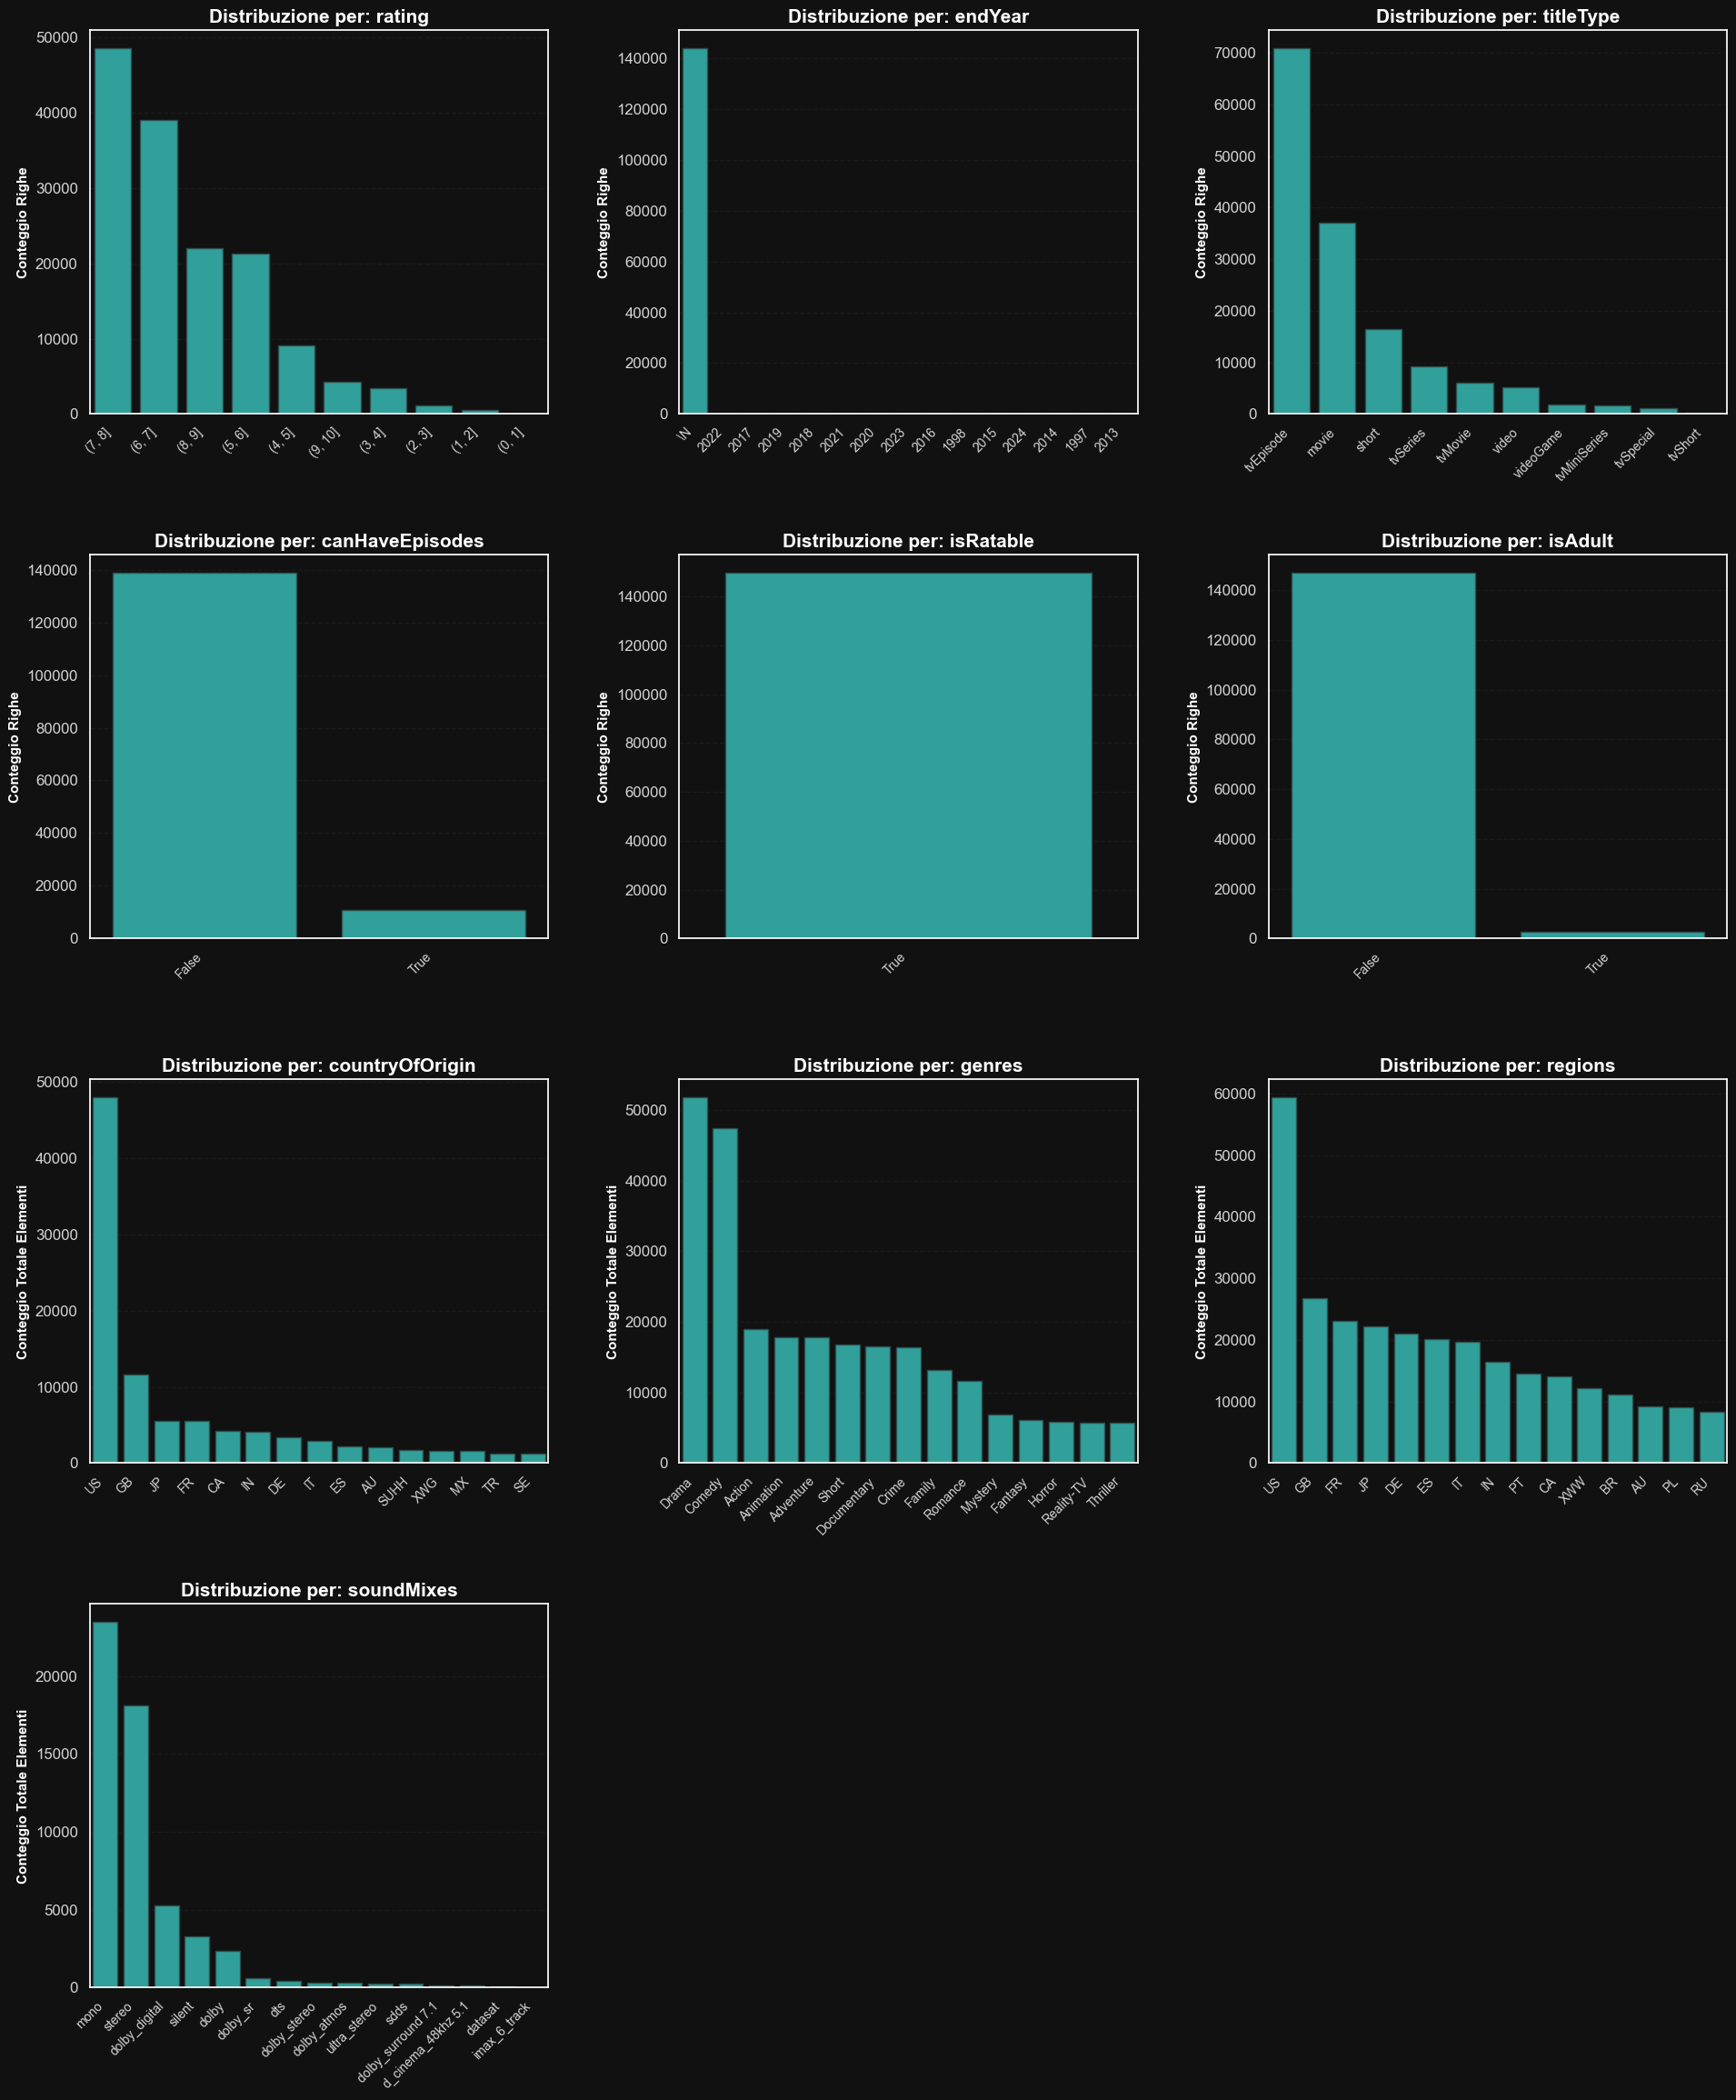

In [12]:
# %% md
#### Dashboard delle Distribuzioni delle Variabili Categoriali USANDO LA FUNZIONE EXPLODE DI PANDAS
# %%
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

# --- 1. Definizione delle Colonne e Stile (dal tuo codice) ---
categorical_cols = [
    "rating",
    "endYear",
    "titleType",
    "canHaveEpisodes",
    "isRatable",
    "isAdult",
    "countryOfOrigin",
    "genres",
    "regions",
    "soundMixes",
]

bar_color = "#20B2AA"  # Verde Acqua (LightSeaGreen)
edge_color = "#2F4F4F"   # DarkSlateGray

# --- 2. Preparazione della Griglia di Plot ---
ncols = 3
nrows = math.ceil(len(categorical_cols) / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 6 * nrows))
axes = axes.flatten()

# --- 3. Plotting sulla Griglia ---
for i, col in enumerate(categorical_cols):
    ax = axes[i] # Seleziona l'asse corrente

    try:
        series_no_na = data[col].dropna()
        if series_no_na.empty:
            ax.set_visible(False)
            continue

        # Qui la logica per determinare se la colonna è list-like deve essere robusta
        # perché le colonne come 'endYear' potrebbero contenere stringhe e non liste
        is_list_like = any(isinstance(i, list) for i in series_no_na)

        if is_list_like:
            # CASO 1: La colonna contiene liste
            exploded_series = series_no_na.explode()
            counts = exploded_series.value_counts().nlargest(15)
            sns.barplot(x=counts.index, y=counts.values, ax=ax, color=bar_color, edgecolor=edge_color)
            ax.set_ylabel('Conteggio Totale Elementi', fontsize=11)
        else:
            # CASO 2: La colonna contiene categorie semplici
            order = data[col].value_counts().nlargest(15).index
            sns.countplot(x=data[col], order=order, ax=ax, color=bar_color, edgecolor=edge_color)
            ax.set_ylabel('Conteggio Righe', fontsize=11)

        ax.set_title(f'Distribuzione per: {col}', fontsize=15, fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45, labelsize=10)
        for label in ax.get_xticklabels():
            label.set_ha('right')

    except Exception as e:
        ax.set_title(f"Errore in '{col}'", fontsize=12)
        print(f"Errore durante la visualizzazione della colonna '{col}': {e}")


# --- 4. Pulizia Finale della Griglia ---
# Nascondi gli assi extra non utilizzati
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(pad=3.0)
plt.savefig(plots_dir + 'categorical_raw_distribution.png', dpi=300)
plt.show()

#### ANALISI DELLE CATEGORIE UNICHE

In [13]:
# %% md
#### Analisi delle Top Categorie per Variabile
# %%

categorical_cols = [
    "rating",
    "endYear",
    "titleType",
    "canHaveEpisodes",
    "isRatable",
    "isAdult",
    "countryOfOrigin",
    "genres",
    "regions",
    "soundMixes",
]

print("--- Analisi delle Categorie più Frequenti ---\n")

for col in categorical_cols:
    series_no_na = data[col].dropna()
    if series_no_na.empty:
        print(f"\n--- Colonna '{col}' è vuota o tutta NaN ---\n")
        continue

    is_list_like = any(isinstance(i, list) for i in series_no_na)

    if is_list_like:
        exploded_series = series_no_na.explode()
        counts = exploded_series.value_counts().nlargest(15)
        print(f"\n--- Top 15 categorie per '{col}' (da liste esplose) ---")
        print(counts)
    else:
        counts = data[col].value_counts().nlargest(15)
        print(f"\n--- Top 15 categorie per '{col}' (semplice) ---")
        print(counts)

    print("-" * 50)

--- Analisi delle Categorie più Frequenti ---


--- Top 15 categorie per 'rating' (semplice) ---
rating
(7, 8]     48550
(6, 7]     39026
(8, 9]     22066
(5, 6]     21325
(4, 5]      9086
(9, 10]     4281
(3, 4]      3443
(2, 3]      1182
(1, 2]       474
(0, 1]        88
Name: count, dtype: int64
--------------------------------------------------

--- Top 15 categorie per 'endYear' (semplice) ---
endYear
\N      143887
2022       241
2017       222
2019       211
2018       206
2021       198
2020       198
2023       195
2016       162
1998       142
2015       128
2024       124
2014       122
1997       122
2013       119
Name: count, dtype: int64
--------------------------------------------------

--- Top 15 categorie per 'titleType' (semplice) ---
titleType
tvEpisode       70822
movie           37098
short           16378
tvSeries         9205
tvMovie          6057
video            5147
videoGame        1777
tvMiniSeries     1619
tvSpecial        1149
tvShort           269
Name:

### CORRELAZIONI VARIABILI CATEGORICHE tramite CRAMER'S V

Colonne selezionate per l'analisi:
['rating', 'endYear', 'titleType', 'canHaveEpisodes', 'isRatable', 'isAdult', 'countryOfOrigin', 'genres', 'regions', 'soundMixes']



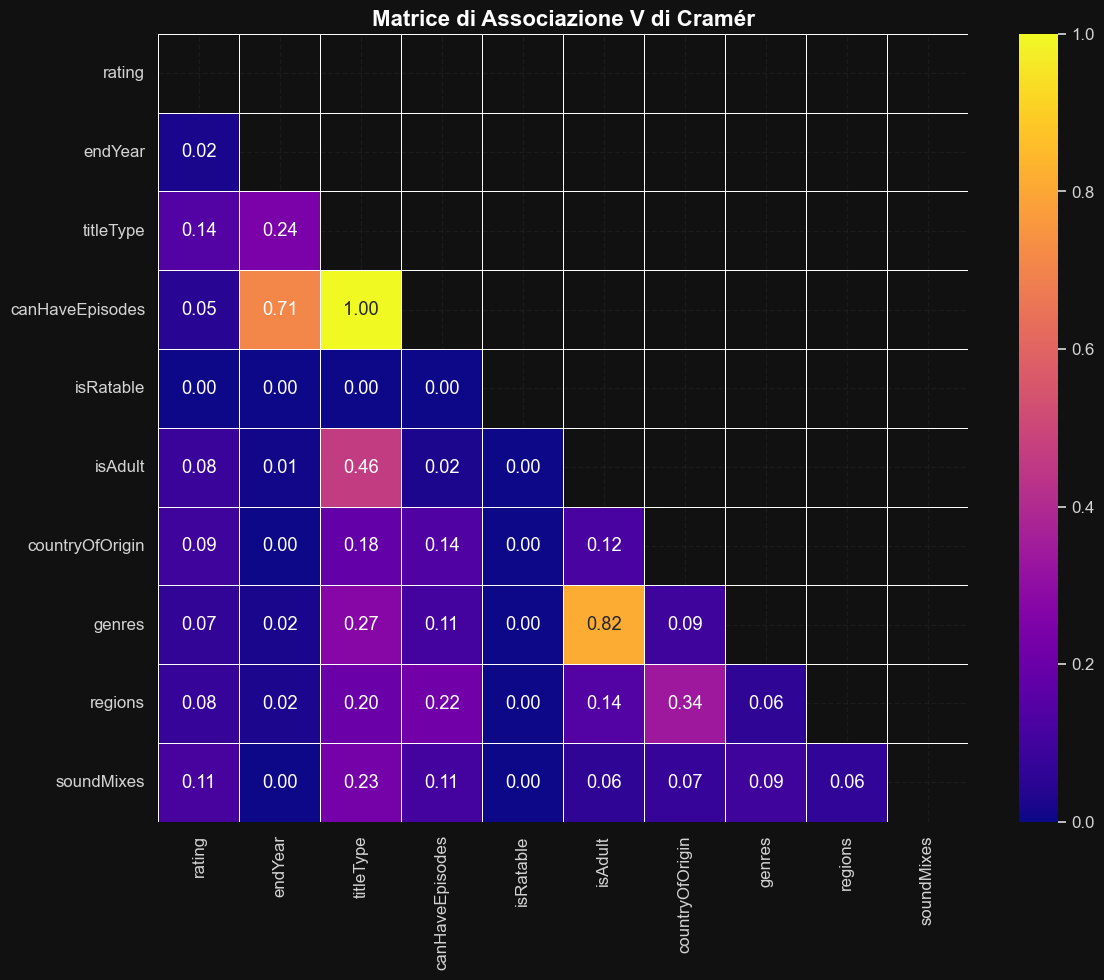


--- Coppie con Associazione più Forte (V di Cramér) ---
titleType ↔ canHaveEpisodes: 1.000
isAdult ↔ genres: 0.816
endYear ↔ canHaveEpisodes: 0.708
titleType ↔ isAdult: 0.461
countryOfOrigin ↔ regions: 0.337
titleType ↔ genres: 0.274
endYear ↔ titleType: 0.240
titleType ↔ soundMixes: 0.227
canHaveEpisodes ↔ regions: 0.217
titleType ↔ regions: 0.201
titleType ↔ countryOfOrigin: 0.180
isAdult ↔ regions: 0.144
rating ↔ titleType: 0.141
canHaveEpisodes ↔ countryOfOrigin: 0.139
isAdult ↔ countryOfOrigin: 0.119


In [14]:
# %% md
#### 2.4 Analisi di Correlazione: Variabili Categoriali (V di Cramér - Finale)
# %%
# OBIETTIVO:
# Misurare l'associazione tra le variabili categoriali, assicurandosi di includere
# le importanti colonne multi-etichetta come 'genres', 'regions', etc.
#
# LOGICA FINALE:
# La selezione delle colonne è stata modificata:
# 1. Si selezionano le colonne categoriali semplici con bassa cardinalità.
# 2. Si aggiungono esplicitamente le colonne multi-etichetta ('genres', 'regions', etc.)
#    che vogliamo analizzare, a prescindere dalla loro cardinalità.
# Questo garantisce un'analisi completa senza escludere feature importanti.

from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_cramer_v(df, cardinality_threshold=50):
    """
    Calcola e visualizza la matrice V di Cramér, includendo le colonne multi-etichetta.
    """

    def cramers_v_corrected(x, y):
        temp_df = pd.DataFrame({'x': x, 'y': y}).dropna()
        if temp_df.empty: return 0.0

        # Gestione robusta per determinare se una colonna è list-like
        is_x_list = temp_df['x'].apply(isinstance, args=([list])).any()
        if is_x_list: temp_df = temp_df.explode('x')

        is_y_list = temp_df['y'].apply(isinstance, args=([list])).any()
        if is_y_list: temp_df = temp_df.explode('y')

        confusion_matrix = pd.crosstab(temp_df['x'], temp_df['y'])
        if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2: return 0.0

        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        phi2 = chi2 / n
        r, k = confusion_matrix.shape
        phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
        rcorr = r - ((r - 1)**2) / (n - 1)
        kcorr = k - ((k - 1)**2) / (n - 1)
        if min((kcorr - 1), (rcorr - 1)) <= 0: return 0.0
        return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


    print(f"Colonne selezionate per l'analisi:\n{categorical_cols}\n")

    # --- 2. Calcolo Matrice e Stampa Coppie ---
    corr_matrix = pd.DataFrame(np.nan, index=categorical_cols, columns=categorical_cols)
    corr_list = []

    for i in range(len(categorical_cols)):
        for j in range(i, len(categorical_cols)):
            col1, col2 = categorical_cols[i], categorical_cols[j]
            v = cramers_v_corrected(df[col1], df[col2])
            corr_matrix.loc[col1, col2] = v
            corr_matrix.loc[col2, col1] = v
            if i != j:
                corr_list.append(((col1, col2), v))

    # --- 3. Heatmap e Stampa dei Risultati ---
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="plasma", vmin=0, vmax=1, linewidths=.5)
    plt.title("Matrice di Associazione V di Cramér", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(plots_dir + 'cramers_v_matrix.png', dpi=300)
    plt.show()

    corr_list.sort(key=lambda x: x[1], reverse=True)
    print("\n--- Coppie con Associazione più Forte (V di Cramér) ---")
    for (col1, col2), v in corr_list[:15]: # Mostriamo le prime 15
        print(f"{col1} ↔ {col2}: {v:.3f}")

# --- Eseguiamo l'analisi ---
analyze_cramer_v(data)

#### Gestione Ridondanza variabili categoriche

In [15]:
"""
ELIMINAZIONE isRatable, motivazione immediata -> zero varianza, la colonna contiene un solo valore unico ripetuto.
ELIMINAZIONE isAdult, correlata al 0.82 con la variabile 'genres'
ELIMINAZIONE 'canHaveEpisodes' essendo correlata al 100% con 'titleType'
"""

"\nELIMINAZIONE isRatable, motivazione immediata -> zero varianza, la colonna contiene un solo valore unico ripetuto.\nELIMINAZIONE isAdult, correlata al 0.82 con la variabile 'genres'\nELIMINAZIONE 'canHaveEpisodes' essendo correlata al 100% con 'titleType'\n"

In [16]:
print(" Eliminazione delle colonna ridondanti 'isRatable', 'isAdult', 'canHaveEpisodes'")
data.drop(columns=['isRatable', 'isAdult', 'canHaveEpisodes'], inplace=True)

# le nuove colonne categoriche sono:
categorical_cols = [
    "rating",
    "endYear",
    "titleType",
    "countryOfOrigin",
    "genres",
    "regions",
    "soundMixes",
]

 Eliminazione delle colonna ridondanti 'isRatable', 'isAdult', 'canHaveEpisodes'


#### TRASFORMAZIONI DI VARIABILI CATEGORICHE

In [17]:
# Trasformazione variabile rating nella sua versione ordinale
# Definiamo l'ordine corretto delle categorie di rating
rating_order = [
    '(0, 1]', '(1, 2]', '(2, 3]', '(3, 4]', '(4, 5]',
    '(5, 6]', '(6, 7]', '(7, 8]', '(8, 9]', '(9, 10]'
]

# Creiamo un dizionario di mappatura
rating_map = {label: i for i, label in enumerate(rating_order)}

# Applichiamo la mappatura
data['rating_encoded'] = data['rating'].map(rating_map)

print("✅ Colonna 'rating' trasformata con Ordinal Encoding.")
print(data[['rating', 'rating_encoded']].head())

✅ Colonna 'rating' trasformata con Ordinal Encoding.
   rating  rating_encoded
0  (5, 6]               5
1  (5, 6]               5
2  (4, 5]               4
3  (5, 6]               5
4  (7, 8]               7


In [18]:
# One-Hot Encode per la variabile categorica titleType
title_dummies = pd.get_dummies(data['titleType'], prefix='type', dtype=int)

# Uniamo le nuove colonne al DataFrame principale
data = pd.concat([data, title_dummies], axis=1)

# Eliminiamo la colonna originale
data.drop('titleType', axis=1, inplace=True)

print("✅ Colonna 'titleType' trasformata con One-Hot Encoding.")
print(data[[col for col in data.columns if 'type_' in col]].head())

✅ Colonna 'titleType' trasformata con One-Hot Encoding.
   type_movie  type_short  type_tvEpisode  type_tvMiniSeries  type_tvMovie  \
0           0           1               0                  0             0   
1           0           1               0                  0             0   
2           0           1               0                  0             0   
3           0           1               0                  0             0   
4           0           1               0                  0             0   

   type_tvSeries  type_tvShort  type_tvSpecial  type_video  type_videoGame  
0              0             0               0           0               0  
1              0             0               0           0               0  
2              0             0               0           0               0  
3              0             0               0           0               0  
4              0             0               0           0               0  


In [19]:
#### Top-N Multi-Label Binarization
def binarize_multilabel_top_n(df, column_name, top_n=20):
    """
    Applica la binarizzazione multi-etichetta per le N categorie più frequenti.

    Args:
        df (pd.DataFrame): Il DataFrame di input.
        column_name (str): Il nome della colonna (che contiene liste).
        top_n (int): Il numero di categorie top da considerare.

    Returns:
        pd.DataFrame: Il DataFrame con le nuove colonne binarie.
    """
    # 1. Troviamo le N categorie più frequenti
    top_categories = df[column_name].explode().value_counts().nlargest(top_n).index

    print(f"--- Binarizzazione per '{column_name}' (Top {top_n}) ---")
    print(f"Categorie più frequenti selezionate: {list(top_categories)}")

    # 2. Creiamo una colonna binaria per ogni categoria top
    for category in top_categories:
        new_col_name = f"{column_name}_{category.lower().replace(' ', '_')}"
        df[new_col_name] = df[column_name].apply(lambda x: 1 if category in x else 0)

    # 3. Eliminiamo la colonna originale
    df.drop(column_name, axis=1, inplace=True)
    return df

# Applichiamo la funzione alle nostre colonne
data = binarize_multilabel_top_n(data, 'genres', top_n=20) # I 20 generi più comuni
data = binarize_multilabel_top_n(data, 'countryOfOrigin', top_n=10) # Le 15 nazioni più comuni
data = binarize_multilabel_top_n(data, 'regions', top_n=20)
data = binarize_multilabel_top_n(data, 'soundMixes', top_n=5)

print("\n✅ Colonne multi-etichetta trasformate con successo.")

--- Binarizzazione per 'genres' (Top 20) ---
Categorie più frequenti selezionate: ['Drama', 'Comedy', 'Action', 'Animation', 'Adventure', 'Short', 'Documentary', 'Crime', 'Family', 'Romance', 'Mystery', 'Fantasy', 'Horror', 'Reality-TV', 'Thriller', 'Music', 'History', 'Sci-Fi', 'Talk-Show', 'Game-Show']
--- Binarizzazione per 'countryOfOrigin' (Top 10) ---
Categorie più frequenti selezionate: ['US', 'GB', 'JP', 'FR', 'CA', 'IN', 'DE', 'IT', 'ES', 'AU']
--- Binarizzazione per 'regions' (Top 20) ---
Categorie più frequenti selezionate: ['US', 'GB', 'FR', 'JP', 'DE', 'ES', 'IT', 'IN', 'PT', 'CA', 'XWW', 'BR', 'AU', 'PL', 'RU', 'HU', 'GR', 'SE', 'FI', 'MX']
--- Binarizzazione per 'soundMixes' (Top 5) ---
Categorie più frequenti selezionate: ['mono', 'stereo', 'dolby_digital', 'silent', 'dolby']

✅ Colonne multi-etichetta trasformate con successo.


#### Trattiamo ora le variabili numeriche e le loro distribuzioni e correlazioni di Pearson (lineari) e Spearman (monotoniche e quindi non lineari)

In [20]:
import numpy as np

# Sostituiamo il placeholder '\\N' con il NaN di NumPy
data['runtimeMinutes'] = data['runtimeMinutes'].replace('\\N', np.nan)

# Convertiamo la colonna in un tipo numerico, forzando gli errori a NaN
data['runtimeMinutes'] = data['runtimeMinutes'].astype(float)

# Calcoliamo e stampiamo la percentuale di valori mancanti
missing_percentage = data['runtimeMinutes'].isnull().sum() * 100 / len(data)
print(f"✅ Colonna 'runtimeMinutes' convertita in numerico.")
print(f"   Percentuale di valori mancanti: {missing_percentage:.2f}%")

✅ Colonna 'runtimeMinutes' convertita in numerico.
   Percentuale di valori mancanti: 26.88%


In [21]:
data.head(20)

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,worstRating,bestRating,totalImages,...,regions_hu,regions_gr,regions_se,regions_fi,regions_mx,soundMixes_mono,soundMixes_stereo,soundMixes_dolby_digital,soundMixes_silent,soundMixes_dolby
0,Carmencita,"(5, 6]",1894,\N,1.0,0,2089,1,10,2,...,1,1,0,0,0,0,0,0,1,0
1,Un bon bock,"(5, 6]",1892,\N,12.0,0,183,1,10,2,...,1,0,0,0,0,0,0,0,1,0
2,Chinese Opium Den,"(4, 5]",1894,\N,1.0,0,195,1,10,1,...,1,0,0,0,0,0,0,0,1,0
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,\N,1.0,1,2237,1,10,3,...,1,0,0,0,0,0,0,0,1,0
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,\N,1.0,0,13115,1,10,12,...,1,0,0,1,0,0,0,0,1,0
5,Autour d'une cabine,"(6, 7]",1894,\N,2.0,0,1220,1,10,15,...,1,0,0,0,0,0,0,0,1,0
6,Place des Cordeliers à Lyon,"(5, 6]",1895,\N,1.0,0,1235,1,10,5,...,0,0,0,0,0,0,0,0,1,0
7,La voltige,"(5, 6]",1895,\N,1.0,0,1104,1,10,5,...,0,0,0,1,0,0,0,0,1,0
8,L'arroseur,"(5, 6]",1896,\N,1.0,0,84,1,10,1,...,0,0,0,0,0,0,0,0,1,0
9,The Ball Game,"(4, 5]",1898,\N,1.0,0,220,1,10,1,...,0,0,0,0,0,0,0,0,1,0


### Distribuzione delle variabili numeriche

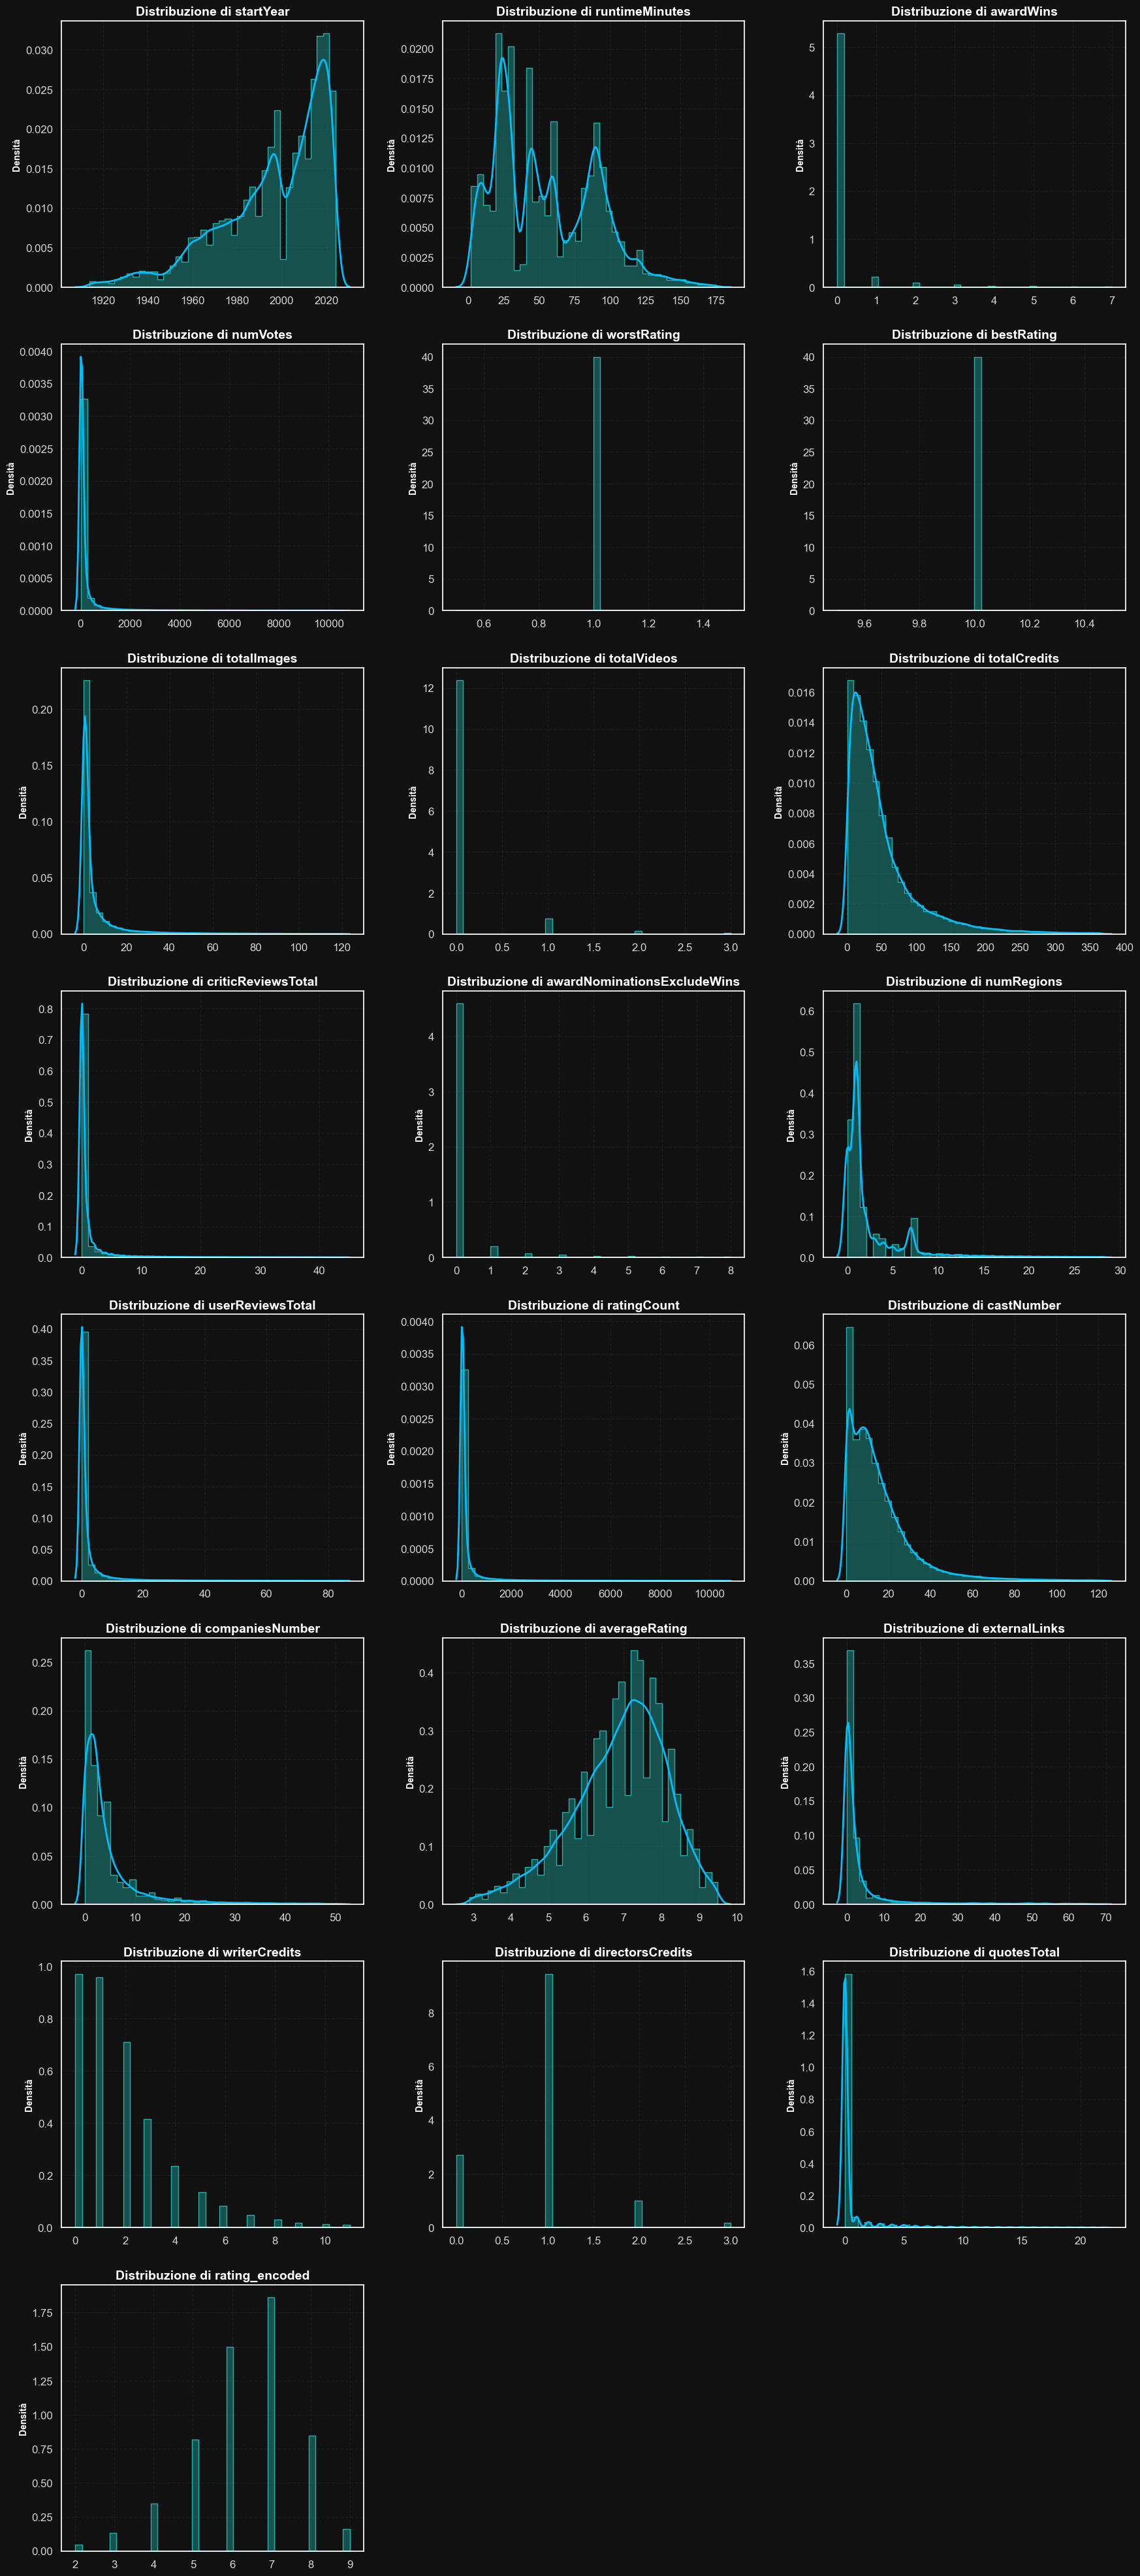

In [22]:
# %% md
#### Dashboard delle Distribuzioni delle Variabili Numeriche GREZZE con scaling dinamicp
# %%
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

# Selezione delle Colonne Numeriche
numeric_cols = [
    'startYear',
    'runtimeMinutes',
    'awardWins',
    'numVotes',
    'worstRating',
    'bestRating',
    'totalImages',
    'totalVideos',
    'totalCredits',
    'criticReviewsTotal',
    'awardNominationsExcludeWins',
    'numRegions',
    'userReviewsTotal',
    'ratingCount',
    'castNumber',
    'companiesNumber',
    'averageRating',
    'externalLinks',
    'writerCredits',
    'directorsCredits',
    'quotesTotal',
    'rating_encoded',
]


# --- 2. Preparazione della Griglia di Plot ---
# Definiamo il layout della griglia: 3 colonne
ncols = 3
# Calcoliamo il numero di righe necessarie per contenere tutti i grafici
nrows = math.ceil(len(numeric_cols) / ncols)

# Creiamo la figura e la griglia di assi
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))

# "Appiattiamo" l'array di assi per poterlo iterare facilmente con un singolo indice
axes = axes.flatten()

# --- 3. Plotting sulla Griglia ---
histogram_color = "#20B2AA"  # Verde Acqua (LightSeaGreen)
kde_color = "#00BFFF"        # Azzurro (DeepSkyBlue)

for i, col in enumerate(numeric_cols):
    ax = axes[i] # Seleziona l'asse corrente per questo grafico

    try:
        series = pd.to_numeric(data[col], errors='coerce').dropna()

        if series.empty:
            ax.set_title(f"Colonna '{col}' vuota", fontsize=12)
            ax.set_visible(False) # Nascondi l'asse se la colonna è vuota
            continue

        # Riduci gli outlier per una visualizzazione più chiara
        lower = series.quantile(0.01)
        upper = series.quantile(0.99)
        trimmed_series = series[(series >= lower) & (series <= upper)]

        # Disegna l'istogramma sull'asse corrente 'ax'
        sns.histplot(
            x=trimmed_series,
            bins=40,
            element="step",
            fill=True,
            alpha=0.4,
            color=histogram_color,
            kde=False,
            stat="density",
            ax=ax
        )

        # Aggiungi il KDE se la variabile è continua
        if trimmed_series.nunique() > 15:
            sns.kdeplot(
                x=trimmed_series,
                color=kde_color,
                linewidth=2,
                ax=ax
            )

        ax.set_title(f'Distribuzione di {col}', fontsize=14, fontweight='bold')
        ax.set_xlabel('') # Rimuoviamo l'etichetta x per un look più pulito
        ax.set_ylabel('Densità', fontsize=10)


    except Exception as e:
        ax.set_title(f"Errore in '{col}'", fontsize=12)
        print(f"Errore durante la visualizzazione della colonna '{col}': {e}")

# --- 4. Pulizia Finale della Griglia ---
# Nascondi gli assi extra che non sono stati utilizzati
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

# Applica un layout compatto per evitare sovrapposizioni e mostra la figura finale
plt.tight_layout(pad=2.0)
plt.savefig(plots_dir + 'numerical_raw_distributions.png', dpi=300)
plt.show()

### CORRELAZIONI VARIABILI NUMERICHE (Pearson & Spearman)

In [23]:
### Prima di eseguire le correlazioni eliminiamo le variabili 'worstRating' e 'bestRating' avendo 0 varianza
data.drop(columns=['worstRating', 'bestRating'], inplace=True)

--- Matrice di Correlazione (Pearson) ---


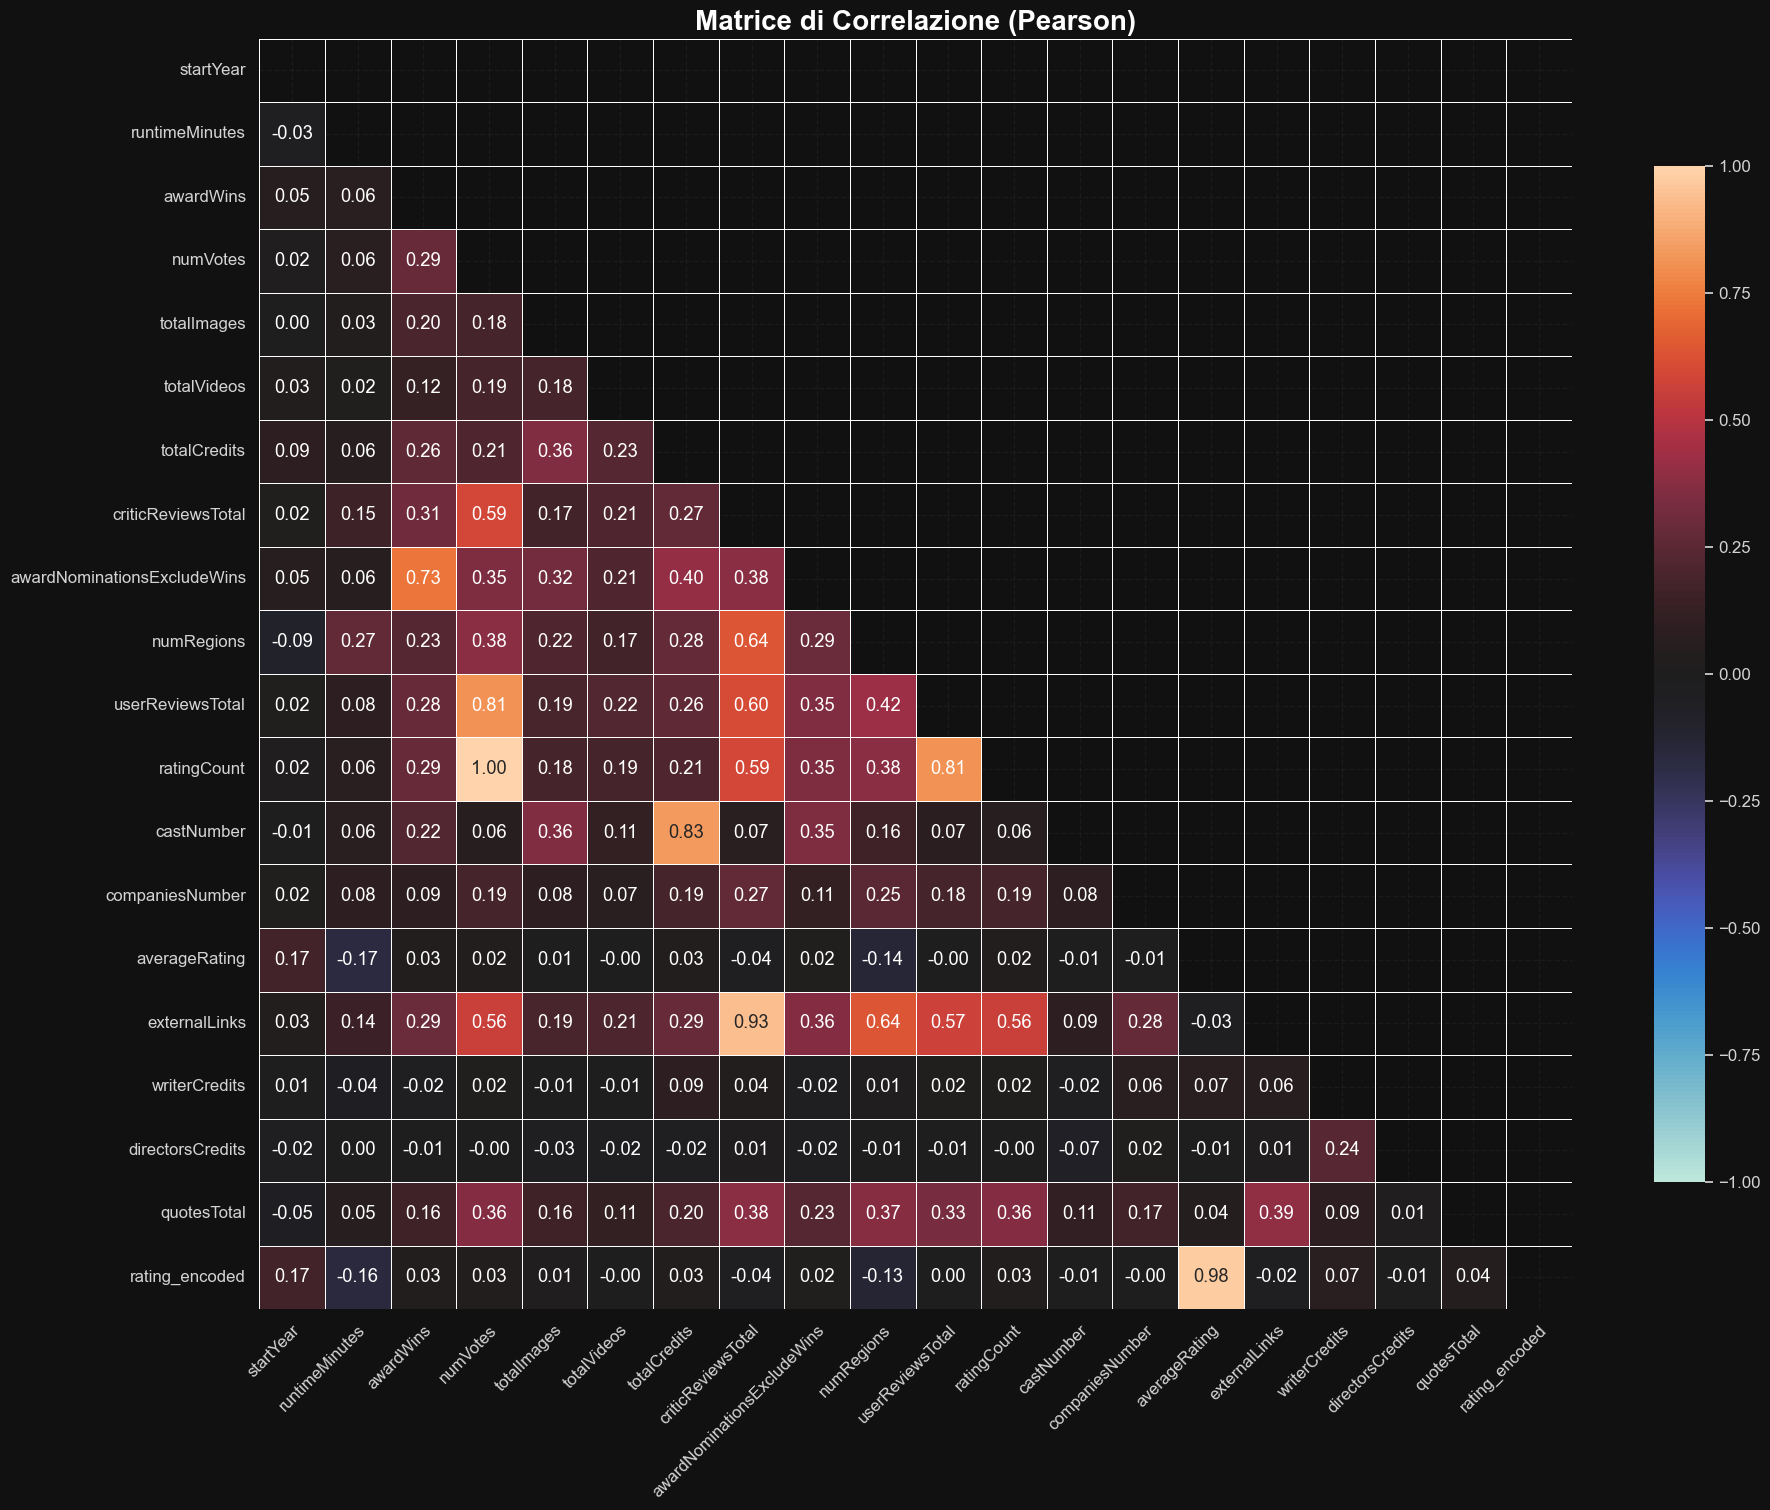


--- Top 15 Correlazioni di Pearson più Forti (Valore Assoluto) ---
1. numVotes ↔ ratingCount: 1.000
2. rating_encoded ↔ averageRating: 0.976
3. externalLinks ↔ criticReviewsTotal: 0.932
4. totalCredits ↔ castNumber: 0.832
5. ratingCount ↔ userReviewsTotal: 0.806
6. numVotes ↔ userReviewsTotal: 0.806
7. awardNominationsExcludeWins ↔ awardWins: 0.730
8. criticReviewsTotal ↔ numRegions: 0.640
9. numRegions ↔ externalLinks: 0.639
10. userReviewsTotal ↔ criticReviewsTotal: 0.603
11. ratingCount ↔ criticReviewsTotal: 0.592
12. numVotes ↔ criticReviewsTotal: 0.592
13. externalLinks ↔ userReviewsTotal: 0.566
14. ratingCount ↔ externalLinks: 0.561
15. externalLinks ↔ numVotes: 0.561
--- Matrice di Correlazione (Spearman) ---


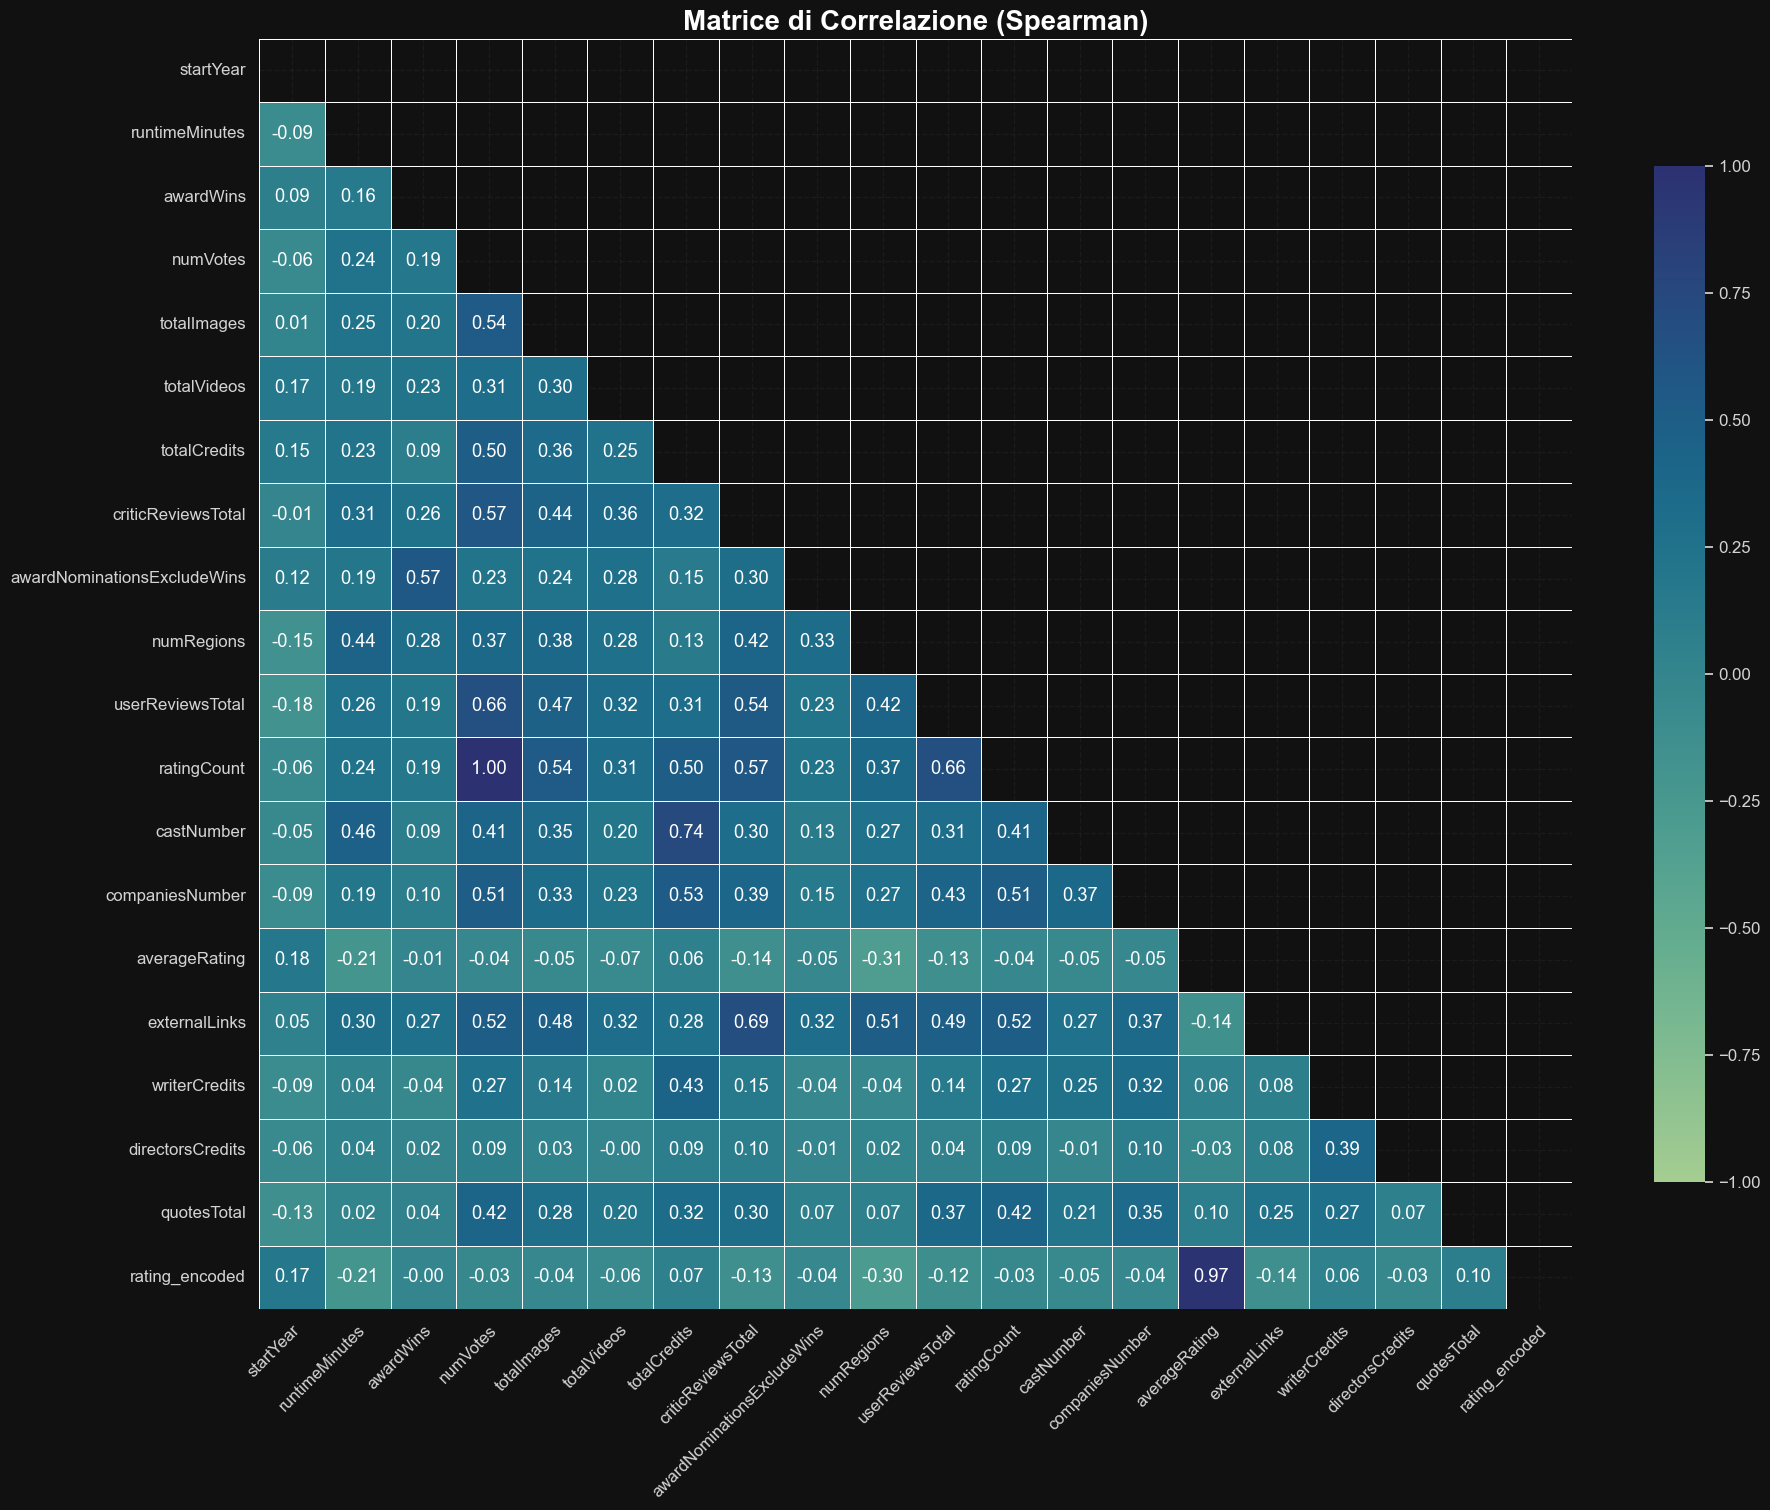


--- Top 15 Correlazioni di Spearman più Forti (Valore Assoluto) ---
1. numVotes ↔ ratingCount: 1.000
2. rating_encoded ↔ averageRating: 0.969
3. castNumber ↔ totalCredits: 0.738
4. externalLinks ↔ criticReviewsTotal: 0.690
5. userReviewsTotal ↔ numVotes: 0.660
6. ratingCount ↔ userReviewsTotal: 0.660
7. ratingCount ↔ criticReviewsTotal: 0.571
8. criticReviewsTotal ↔ numVotes: 0.571
9. awardWins ↔ awardNominationsExcludeWins: 0.567
10. userReviewsTotal ↔ criticReviewsTotal: 0.544
11. totalImages ↔ ratingCount: 0.535
12. numVotes ↔ totalImages: 0.535
13. totalCredits ↔ companiesNumber: 0.529
14. externalLinks ↔ numVotes: 0.515
15. externalLinks ↔ ratingCount: 0.515


In [24]:
# Le tue impostazioni grafiche e la lista di colonne
plt.style.use("dark_background")
sns.set_theme(style="darkgrid", context="notebook", palette="icefire", font="sans-serif", font_scale=1.1)
plt.rcParams.update({
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold', 'axes.edgecolor': 'white',
    'axes.labelcolor': 'white', 'xtick.color': 'lightgray', 'ytick.color': 'lightgray',
    'text.color': 'white', 'grid.color': '#333333', 'grid.linestyle': '--',
    'grid.alpha': 0.3, 'figure.facecolor': '#111111', 'axes.facecolor': '#111111',
    'savefig.facecolor': '#111111'
})

numeric_cols = [
    'startYear', 'runtimeMinutes', 'awardWins', 'numVotes', 'totalImages', 'totalVideos',
    'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions',
    'userReviewsTotal', 'ratingCount', 'castNumber', 'companiesNumber', 'averageRating',
    'externalLinks', 'writerCredits', 'directorsCredits', 'quotesTotal', 'rating_encoded'
]

def plot_correlation_heatmap(df, columns_to_use, method='pearson', my_cmap='icefire', images_dir=''):
    """
    Calcola e visualizza una heatmap di correlazione triangolare
    utilizzando una lista specifica di colonne.
    """
    print(f"--- Matrice di Correlazione ({method.capitalize()}) ---")

    # *** CORREZIONE: Usa la lista di colonne fornita dall'utente ***
    numeric_df = df[columns_to_use].copy() # Usiamo .copy() per evitare SettingWithCopyWarning

    # Gestione esplicita dei NaN per il calcolo della correlazione
    numeric_df.dropna(inplace=True)

    # Calcola la matrice di correlazione
    corr_matrix = numeric_df.corr(method=method)

    # Crea una maschera per nascondere il triangolo superiore
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # Imposta la figura
    plt.figure(figsize=(20, 16))

    # Disegna la heatmap
    sns.heatmap(corr_matrix,
                mask=mask,
                annot=True,
                fmt=".2f",
                cmap=my_cmap,
                vmin=-1,
                vmax=1,
                linewidths=.5,
                cbar_kws={"shrink": .8})

    plt.title(f"Matrice di Correlazione ({method.capitalize()})", fontsize=20, fontweight='bold')
    plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
    plt.yticks(rotation=0)
    plt.tight_layout(pad=3.0)

    if images_dir:
        plt.savefig(plots_dir + f"correlation_heatmap_{method}.png", dpi=300)

    plt.show()
    return corr_matrix


def print_top_correlations(corr_matrix, method='Pearson', n=15):
    """
    Estrae e stampa le N correlazioni più forti (in valore assoluto) da una matrice.
    """
    # Estrai le correlazioni, escludendo le auto-correlazioni e le simmetriche
    sorted_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
    # Rimuovi le correlazioni di una variabile con se stessa
    sorted_corr = sorted_corr[sorted_corr < 1.0]

    # Rimuovi le coppie duplicate (es. corr(A,B) e corr(B,A))
    unique_corr_pairs = set()
    top_pairs_list = []
    for (var1, var2), val in sorted_corr.items():
        if (var2, var1) not in unique_corr_pairs:
            unique_corr_pairs.add((var1, var2))
            top_pairs_list.append(((var1, var2), val))

    print(f"\n--- Top {n} Correlazioni di {method} più Forti (Valore Assoluto) ---")

    # Stampa i risultati formattati
    for i, ((var1, var2), abs_val) in enumerate(top_pairs_list):
        if i >= n:
            break
        original_val = corr_matrix.loc[var1, var2]
        print(f"{i+1}. {var1} ↔ {var2}: {original_val:.3f}")

# --- ESECUZIONE DELL'ANALISI CORRETTA ---

# Eseguiamo l'analisi per Pearson
pearson_corr = plot_correlation_heatmap(data, columns_to_use=numeric_cols, method='pearson', my_cmap='icefire', images_dir=plots_dir)
print_top_correlations(pearson_corr, method='Pearson')

# Eseguiamo l'analisi per Spearman
spearman_corr = plot_correlation_heatmap(data, columns_to_use=numeric_cols, method='spearman', my_cmap='crest', images_dir=plots_dir)
print_top_correlations(spearman_corr, method='Spearman')

#### Utilizziamo le correlazioni per imputare la variabile runtimeMinutes

In [25]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd

# 1. Definiamo le colonne numeriche CORE (senza quelle a varianza zero)
numerical_cols_core = [
    'startYear', 'runtimeMinutes', 'awardWins', 'numVotes', 'totalImages', 'totalVideos',
    'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions',
    'userReviewsTotal', 'ratingCount', 'castNumber', 'companiesNumber', 'averageRating',
    'externalLinks', 'writerCredits', 'directorsCredits', 'quotesTotal',
]

# 2. Identifichiamo le colonne one-hot-encoded di titleType
title_type_cols = [col for col in data.columns if col.startswith('type_')]

# 3. *** LA TUA MOSSA VINCENTE ***: Combiniamo le due liste di colonne
#    Queste sono le feature che guideranno la nostra imputazione intelligente.
imputation_features = numerical_cols_core + title_type_cols

print("--- Feature selezionate per l'imputazione (Numeriche + Categoriche OHE) ---")
print(imputation_features)

# Creiamo una copia del subset di dati per sicurezza
data_to_impute = data[imputation_features].copy()

# 4. Inizializziamo l'imputer
imputer = IterativeImputer(max_iter=10, random_state=42, verbose=2) # Aggiungo verbose per vedere il progresso

print("\n--- Avvio dell'Imputazione Iterativa con feature potenziate ---")

# 5. Applichiamo l'imputer al nostro set di feature potenziato
imputed_data_np = imputer.fit_transform(data_to_impute)

# 6. Ricostruiamo il DataFrame con i dati imputati
imputed_df = pd.DataFrame(imputed_data_np, columns=imputation_features, index=data.index)

# 7. Aggiorniamo la colonna 'runtimeMinutes' nel DataFrame principale con i valori corretti
data['runtimeMinutes'] = imputed_df['runtimeMinutes']

print("\n--- Imputazione completata con successo ---")

# 8. VERIFICA FINALE E CATEGORICA
missing_after = data['runtimeMinutes'].isnull().sum()
print(f"✅ Valori mancanti in 'runtimeMinutes' dopo l'imputazione: {missing_after}")

if missing_after == 0:
    print("\n🎉🎉🎉 MODULO 0 COMPLETATO! 🎉🎉🎉")
    print("Grazie alla tua guida, il nostro dataset è ora un capolavoro di preparazione dati.")
    print("È pulito, coerente, senza valori mancanti e pronto per la modellazione.")
else:
    print("⚠️ Attenzione, c'è ancora un problema da risolvere.")

--- Feature selezionate per l'imputazione (Numeriche + Categoriche OHE) ---
['startYear', 'runtimeMinutes', 'awardWins', 'numVotes', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions', 'userReviewsTotal', 'ratingCount', 'castNumber', 'companiesNumber', 'averageRating', 'externalLinks', 'writerCredits', 'directorsCredits', 'quotesTotal', 'type_movie', 'type_short', 'type_tvEpisode', 'type_tvMiniSeries', 'type_tvMovie', 'type_tvSeries', 'type_tvShort', 'type_tvSpecial', 'type_video', 'type_videoGame']

--- Avvio dell'Imputazione Iterativa con feature potenziate ---
[IterativeImputer] Completing matrix with shape (149521, 29)
[IterativeImputer] Ending imputation round 1/10, elapsed time 3.16
[IterativeImputer] Change: 88.60453830061815, scaled tolerance: 2948.79 
[IterativeImputer] Early stopping criterion reached.

--- Imputazione completata con successo ---
✅ Valori mancanti in 'runtimeMinutes' dopo l'imputazione: 0

🎉🎉🎉 MODUL

In [26]:
data.head(100)

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,...,regions_hu,regions_gr,regions_se,regions_fi,regions_mx,soundMixes_mono,soundMixes_stereo,soundMixes_dolby_digital,soundMixes_silent,soundMixes_dolby
0,Carmencita,"(5, 6]",1894,\N,1.000000,0,2089,2,0,4,...,1,1,0,0,0,0,0,0,1,0
1,Un bon bock,"(5, 6]",1892,\N,12.000000,0,183,2,0,2,...,1,0,0,0,0,0,0,0,1,0
2,Chinese Opium Den,"(4, 5]",1894,\N,1.000000,0,195,1,0,1,...,1,0,0,0,0,0,0,0,1,0
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,\N,1.000000,1,2237,3,0,4,...,1,0,0,0,0,0,0,0,1,0
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,\N,1.000000,0,13115,12,0,11,...,1,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Mr. Jones at the Ball,"(5, 6]",1908,\N,8.000000,0,73,1,0,13,...,0,0,0,0,0,0,0,0,1,0
96,"Old Isaacs, the Pawnbroker","(6, 7]",1908,\N,10.000000,0,32,0,0,6,...,0,0,0,0,0,0,0,0,1,0
97,The Princess in the Vase,"(6, 7]",1908,\N,9.865709,0,16,0,0,5,...,0,0,0,0,0,0,0,0,1,0
98,The Song of the Shirt,"(5, 6]",1908,\N,11.000000,0,145,1,0,13,...,1,0,0,0,0,0,0,0,1,0


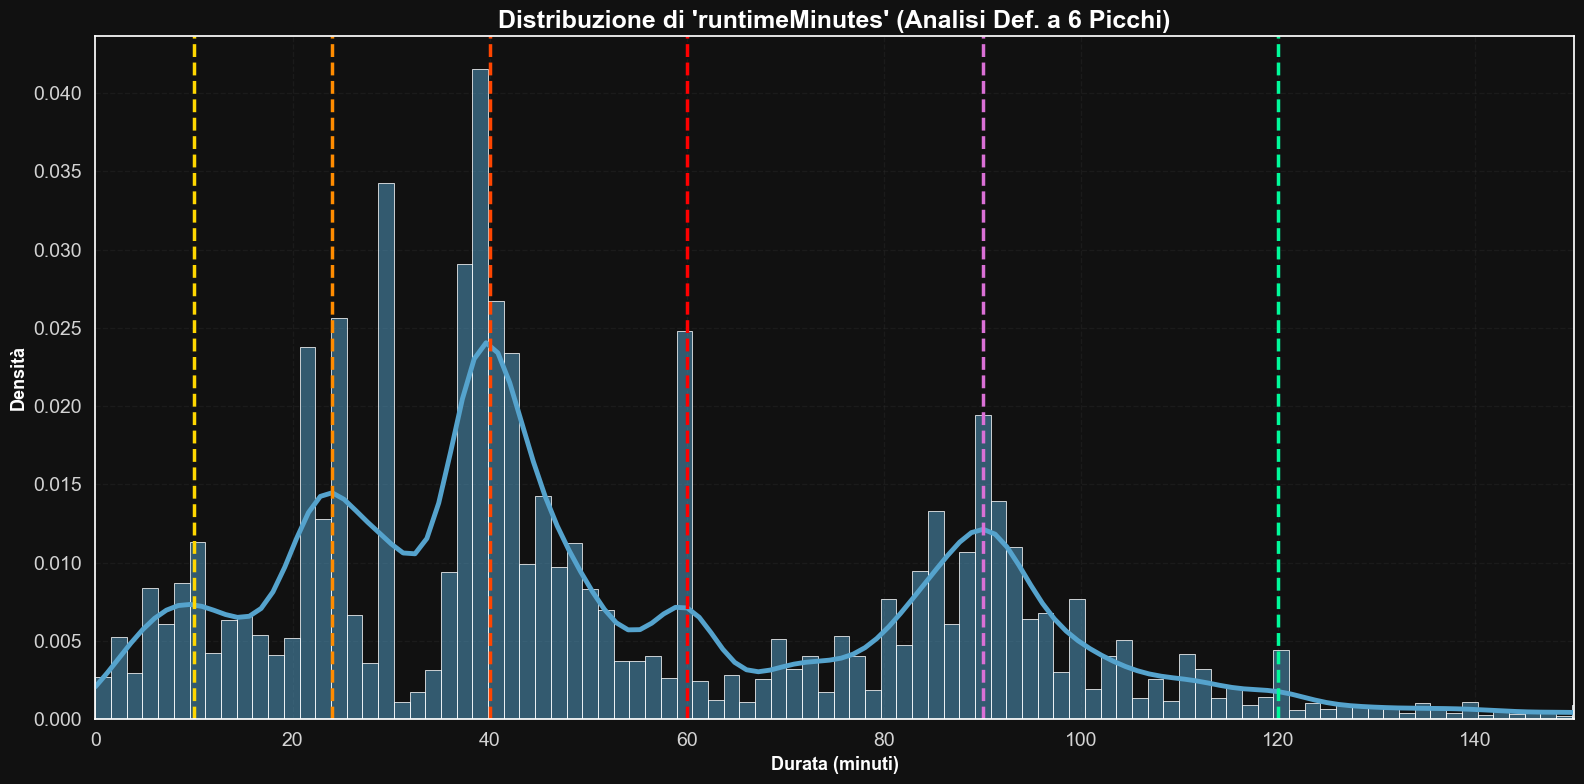

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- IMPOSTAZIONI DEL GRAFICO ---
plt.style.use("dark_background")
sns.set_theme(style="darkgrid", context="notebook", palette="icefire")
plt.rcParams.update({
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold', 'axes.edgecolor': 'white',
    'axes.labelcolor': 'white', 'xtick.color': 'lightgray', 'ytick.color': 'lightgray',
    'text.color': 'white', 'grid.color': '#333333', 'grid.linestyle': '--',
    'grid.alpha': 0.3, 'figure.facecolor': '#111111', 'axes.facecolor': '#111111',
    'savefig.facecolor': '#111111'
})

# --- VISUALIZZAZIONE DELLA DISTRIBUZIONE ---
plt.figure(figsize=(16, 8))  # immagine meno larga per adattarsi al report

# Filtro dati: manteniamo quelli < 240 (ma visualizziamo solo fino a 150)
runtime_visual = data[data['runtimeMinutes'] < 240]['runtimeMinutes']

# Istogramma + KDE
sns.histplot(runtime_visual,
             bins=150,
             kde=True,
             stat="density",
             line_kws={'linewidth': 3.5, 'color': '#00BFFF'})

# Linee dei picchi (senza legenda)
expected_peaks = [10, 24, 40, 60, 90, 120]
peak_colors = ['#FFD700', '#FF8C00', '#FF4500', '#FF0000', '#DA70D6', '#00FA9A']

for i, peak in enumerate(expected_peaks):
    plt.axvline(x=peak,
                color=peak_colors[i],
                linestyle='--',
                linewidth=2.5)

# Titoli e label
plt.title("Distribuzione di 'runtimeMinutes' (Analisi Def. a 6 Picchi)", fontsize=18, fontweight='bold')
plt.xlabel("Durata (minuti)", fontsize=13)
plt.ylabel("Densità", fontsize=13)
plt.xlim(0, 150)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


# Export pulito
plt.tight_layout()
plt.savefig(plots_dir + 'runtime_visual.png', dpi=300)
plt.show()


#### Eliminazione delle colonne numeriche ridondanti (quelle correlate da 79% in su)

In [28]:
"""
ELIMINAZIONE DELLE COLONNE:
    'ratingCount',       # Ridondante con numVotes
    'externalLinks',     # Ridondante con criticReviewsTotal
    'castNumber',        # Ridondante con totalCredits
    'rating_encoded'     # Verrà generata on-demand da averageRating per la classificazione
"""

# Lista definitiva delle colonne da eliminare
columns_to_drop = [
    'ratingCount',       # Ridondante con numVotes
    'externalLinks',     # Ridondante con criticReviewsTotal
    'castNumber',        # Ridondante con totalCredits
    'rating_encoded'     # Verrà generata on-demand da averageRating per la classificazione
]

# Messaggio di log per il nostro taccuino
print("--- Eliminazione Feature Ridondanti (Strategia Definitiva) ---")
print(f"Colonne da eliminare: {columns_to_drop}")

# Eseguiamo l'eliminazione
initial_cols = data.shape[1]
data.drop(columns=columns_to_drop, inplace=True, errors='ignore') # errors='ignore' per non dare errore se già eliminata
final_cols = data.shape[1]

print("\nOperazione completata.")
print(f"Numero di colonne iniziale: {initial_cols}")
print(f"Numero di colonne finale: {final_cols}")
print(f"✅ {len(columns_to_drop)} colonne eliminate con successo.")

# COLONNE NUMERICHE AGGIORNATE:
numeric_cols = [
    'startYear', 'runtimeMinutes', 'awardWins', 'numVotes', 'totalImages', 'totalVideos',
    'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions',
    'userReviewsTotal', 'companiesNumber', 'averageRating', 'externalLinks',
    'writerCredits', 'directorsCredits', 'quotesTotal'
]

print("\n--- Colonne Numeriche Aggiornate ---")
print(numeric_cols)


--- Eliminazione Feature Ridondanti (Strategia Definitiva) ---
Colonne da eliminare: ['ratingCount', 'externalLinks', 'castNumber', 'rating_encoded']

Operazione completata.
Numero di colonne iniziale: 88
Numero di colonne finale: 84
✅ 4 colonne eliminate con successo.

--- Colonne Numeriche Aggiornate ---
['startYear', 'runtimeMinutes', 'awardWins', 'numVotes', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions', 'userReviewsTotal', 'companiesNumber', 'averageRating', 'externalLinks', 'writerCredits', 'directorsCredits', 'quotesTotal']


#### Creazione di variabili interessanti (Feature Engineering)

In [29]:
# ==============================================================================
# PARTE 1: FEATURE ENGINEERING (con nomenclatura camelCase)
# ==============================================================================
print("--- Parte 1: Creazione delle Nuove Feature (camelCase) ---")

# 1. winRate
total_acclaim = data['awardWins'] + data['awardNominationsExcludeWins']
data['winRate'] = np.where(total_acclaim == 0, 0.0, data['awardWins'] / total_acclaim)
print("Creata feature: winRate")

# 2. contentRichness
data['contentRichness'] = data['quotesTotal'] + data['totalVideos'] + data['totalImages'] + data['totalCredits']
print("Creata feature: contentRichness")

# 3. logPopularityScore
popularity_score = data['numVotes'] * (data['userReviewsTotal'] + data['criticReviewsTotal'])
data['logPopularityScore'] = np.log1p(popularity_score)
print("Creata feature: logPopularityScore")

# 4. criticUserRatio
log_critic_reviews = np.log1p(data['criticReviewsTotal'])
log_user_reviews = np.log1p(data['userReviewsTotal'])
data['criticUserRatio'] = np.where(log_user_reviews == 0, 0.0, log_critic_reviews / log_user_reviews)
print("Creata feature: criticUserRatio")

# 5. hasWriterAndDirector
data['hasWriterAndDirector'] = ((data['writerCredits'] > 0) & (data['directorsCredits'] > 0)).astype(int)
print("Creata feature: hasWriterAndDirector")

print("\n Feature engineering completato.")

# Le colonne numeriche aggiornate sono:
numeric_cols = [
    'startYear', 'runtimeMinutes', 'awardWins', 'numVotes', 'totalImages', 'totalVideos',
    'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions',
    'userReviewsTotal', 'companiesNumber', 'averageRating', 'writerCredits', 'directorsCredits', 'quotesTotal',
    'winRate', 'contentRichness', 'logPopularityScore', 'criticUserRatio', 'hasWriterAndDirector'
]

"""
Le colonne numeriche aggiornate sono:
numeric_cols = [
    'startYear', 'runtimeMinutes', 'awardWins', 'numVotes', 'totalImages', 'totalVideos',
    'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions',
    'userReviewsTotal', 'companiesNumber', 'writerCredits', 'directorsCredits', 'quotesTotal',
    'winRate', 'contentRichness', 'logPopularityScore', 'criticUserRatio', 'hasWriterAndDirector'
]
"""

--- Parte 1: Creazione delle Nuove Feature (camelCase) ---
Creata feature: winRate
Creata feature: contentRichness
Creata feature: logPopularityScore
Creata feature: criticUserRatio
Creata feature: hasWriterAndDirector

 Feature engineering completato.


"\nLe colonne numeriche aggiornate sono:\nnumeric_cols = [\n    'startYear', 'runtimeMinutes', 'awardWins', 'numVotes', 'totalImages', 'totalVideos',\n    'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions',\n    'userReviewsTotal', 'companiesNumber', 'writerCredits', 'directorsCredits', 'quotesTotal',\n    'winRate', 'contentRichness', 'logPopularityScore', 'criticUserRatio', 'hasWriterAndDirector'\n]\n"

In [30]:
data.head()

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,...,soundMixes_mono,soundMixes_stereo,soundMixes_dolby_digital,soundMixes_silent,soundMixes_dolby,winRate,contentRichness,logPopularityScore,criticUserRatio,hasWriterAndDirector
0,Carmencita,"(5, 6]",1894,\N,1.0,0,2089,2,0,4,...,0,0,0,1,0,0.0,6,10.588905,0.489301,0
1,Un bon bock,"(5, 6]",1892,\N,12.0,0,183,2,0,2,...,0,0,0,1,0,0.0,4,5.214936,0.000000,0
2,Chinese Opium Den,"(4, 5]",1894,\N,1.0,0,195,1,0,1,...,0,0,0,1,0,0.0,2,0.000000,0.000000,0
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,\N,1.0,1,2237,3,0,4,...,0,0,0,1,0,1.0,7,10.803954,0.360849,0
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,\N,1.0,0,13115,12,0,11,...,0,0,0,1,0,0.0,23,13.888232,0.673822,0


#### Distribuzioni grezze delle nuove variabili create

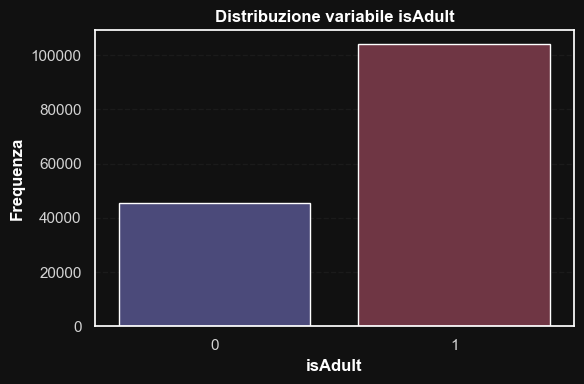

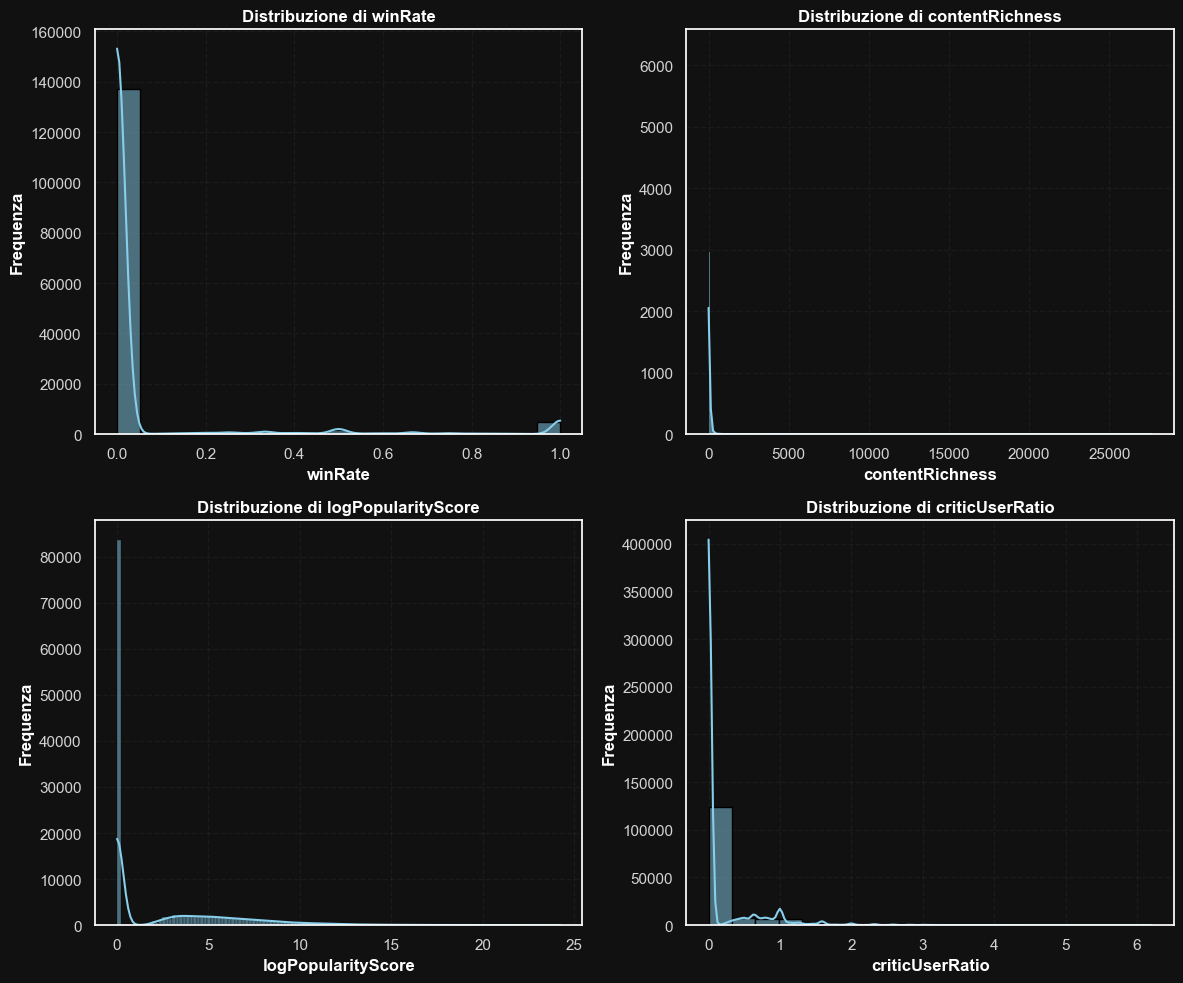

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plottiamo la booleana 'hasWriterAndDirector'
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='hasWriterAndDirector', hue='hasWriterAndDirector', palette="icefire", legend=False)
plt.title('Distribuzione variabile isAdult')
plt.ylabel('Frequenza')
plt.xlabel('isAdult')
plt.tight_layout()
plt.show()


# plottiamo le restanti variabili continue
vars_continue = ['winRate', 'contentRichness', 'logPopularityScore', 'criticUserRatio']


plt.figure(figsize=(12, 10))
# Loop per plottare ogni distribuzione
for i, var in enumerate(vars_continue, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=data, x=var, kde=True, color='skyblue', edgecolor='black')
    plt.title(f'Distribuzione di {var}', fontsize=12)
    plt.xlabel(var)
    plt.ylabel('Frequenza')

plt.tight_layout()
plt.show()



#### TRASFORMAZIONI ALLE VARIABLI NUMERICHE: Yeo-Johnson con standardizzazione

In [32]:
from sklearn.preprocessing import RobustScaler, PowerTransformer, StandardScaler
import numpy as np
import pandas as pd

numeric_cols = [
    'startYear', 'runtimeMinutes', 'awardWins', 'numVotes', 'totalImages', 'totalVideos',
    'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'numRegions',
    'userReviewsTotal', 'companiesNumber', 'averageRating', 'writerCredits', 'directorsCredits', 'quotesTotal',
    'winRate', 'contentRichness', 'logPopularityScore', 'criticUserRatio',
]


# Nomi per le nuove colonne
processed_cols_names = [f"{col}_proc" for col in numeric_cols]

print("--- Procedura a 3 Fasi Anti-Overflow ---")

# Estraiamo i dati da trasformare
data_subset = data[numeric_cols].copy()

# --- FASE 1: Pre-scaling con RobustScaler per domare gli outlier ---
print("\nFase 1: Applicazione di RobustScaler per la stabilità numerica...")
robust_scaler = RobustScaler()
robust_scaled_data = robust_scaler.fit_transform(data_subset)

# --- FASE 2: Trasformazione Yeo-Johnson sui dati pre-scalati ---
print("Fase 2: Applicazione di PowerTransformer (Yeo-Johnson)...")
power_transformer = PowerTransformer(method='yeo-johnson', standardize=False)
transformed_data = power_transformer.fit_transform(robust_scaled_data)

# --- FASE 3: Standardizzazione finale ---
print("Fase 3: Applicazione di StandardScaler per la scalatura finale (media 0, std 1)...")
final_scaler = StandardScaler()
final_data = final_scaler.fit_transform(transformed_data)

# 4. Aggiungiamo i dati finali al DataFrame con i nuovi nomi
data[processed_cols_names] = final_data
print("\nOperazione completata con successo. Nessun warning previsto.")

# --- VERIFICA FINALE ---
print(f"\nCreate {len(processed_cols_names)} nuove colonne '_proc'. Le colonne originali sono intatte.")
print("\nStatistiche delle nuove colonne '_proc':")
print(data[processed_cols_names].describe().loc[['mean', 'std']])

--- Procedura a 3 Fasi Anti-Overflow ---

Fase 1: Applicazione di RobustScaler per la stabilità numerica...
Fase 2: Applicazione di PowerTransformer (Yeo-Johnson)...
Fase 3: Applicazione di StandardScaler per la scalatura finale (media 0, std 1)...

Operazione completata con successo. Nessun warning previsto.

Create 20 nuove colonne '_proc'. Le colonne originali sono intatte.

Statistiche delle nuove colonne '_proc':
      startYear_proc  runtimeMinutes_proc  awardWins_proc  numVotes_proc  \
mean    3.041361e-18        -9.656321e-17   -2.570901e-17   3.041361e-17   
std     1.000003e+00         1.000003e+00    1.000003e+00   1.000003e+00   

      totalImages_proc  totalVideos_proc  totalCredits_proc  \
mean      7.375301e-17     -5.322382e-18       1.720270e-17   
std       1.000003e+00      1.000003e+00       1.000003e+00   

      criticReviewsTotal_proc  awardNominationsExcludeWins_proc  \
mean             2.090936e-18                     -9.475741e-17   
std              1.000003

In [33]:
data.head()

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,totalImages,totalVideos,totalCredits,...,userReviewsTotal_proc,companiesNumber_proc,averageRating_proc,writerCredits_proc,directorsCredits_proc,quotesTotal_proc,winRate_proc,contentRichness_proc,logPopularityScore_proc,criticUserRatio_proc
0,Carmencita,"(5, 6]",1894,\N,1.0,0,2089,2,0,4,...,1.836167,0.168822,-0.919474,-1.33565,0.244167,-0.400731,-0.299870,-1.486015,1.552267,2.102152
1,Un bon bock,"(5, 6]",1892,\N,12.0,0,183,2,0,2,...,0.777289,-1.530391,-1.099138,-1.33565,0.244167,-0.400731,-0.299870,-1.611139,1.082526,-0.465842
2,Chinese Opium Den,"(4, 5]",1894,\N,1.0,0,195,1,0,1,...,-0.737922,-0.766296,-1.328129,-1.33565,0.244167,-0.400731,-0.299870,-1.740513,-0.863379,-0.465842
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,\N,1.0,1,2237,3,0,4,...,1.855327,0.821188,-1.099138,-1.33565,0.244167,-0.400731,3.347882,-1.425032,1.562992,1.995890
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,\N,1.0,0,13115,12,0,11,...,1.904733,0.654420,0.296101,-1.33565,1.435843,-0.400731,-0.299870,-0.587026,1.683882,2.160761


In [34]:
data.info(verbose=True, memory_usage=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 149521 entries, 0 to 149530
Data columns (total 109 columns):
 #    Column                            Non-Null Count   Dtype  
---   ------                            --------------   -----  
 0    originalTitle                     149521 non-null  object 
 1    rating                            149521 non-null  object 
 2    startYear                         149521 non-null  int64  
 3    endYear                           149521 non-null  object 
 4    runtimeMinutes                    149521 non-null  float64
 5    awardWins                         149521 non-null  int64  
 6    numVotes                          149521 non-null  int64  
 7    totalImages                       149521 non-null  int64  
 8    totalVideos                       149521 non-null  int64  
 9    totalCredits                      149521 non-null  int64  
 10   criticReviewsTotal                149521 non-null  int64  
 11   awardNominationsExcludeWins       149521 n

#### Visualizzazione Variabili Numeriche Trasformate

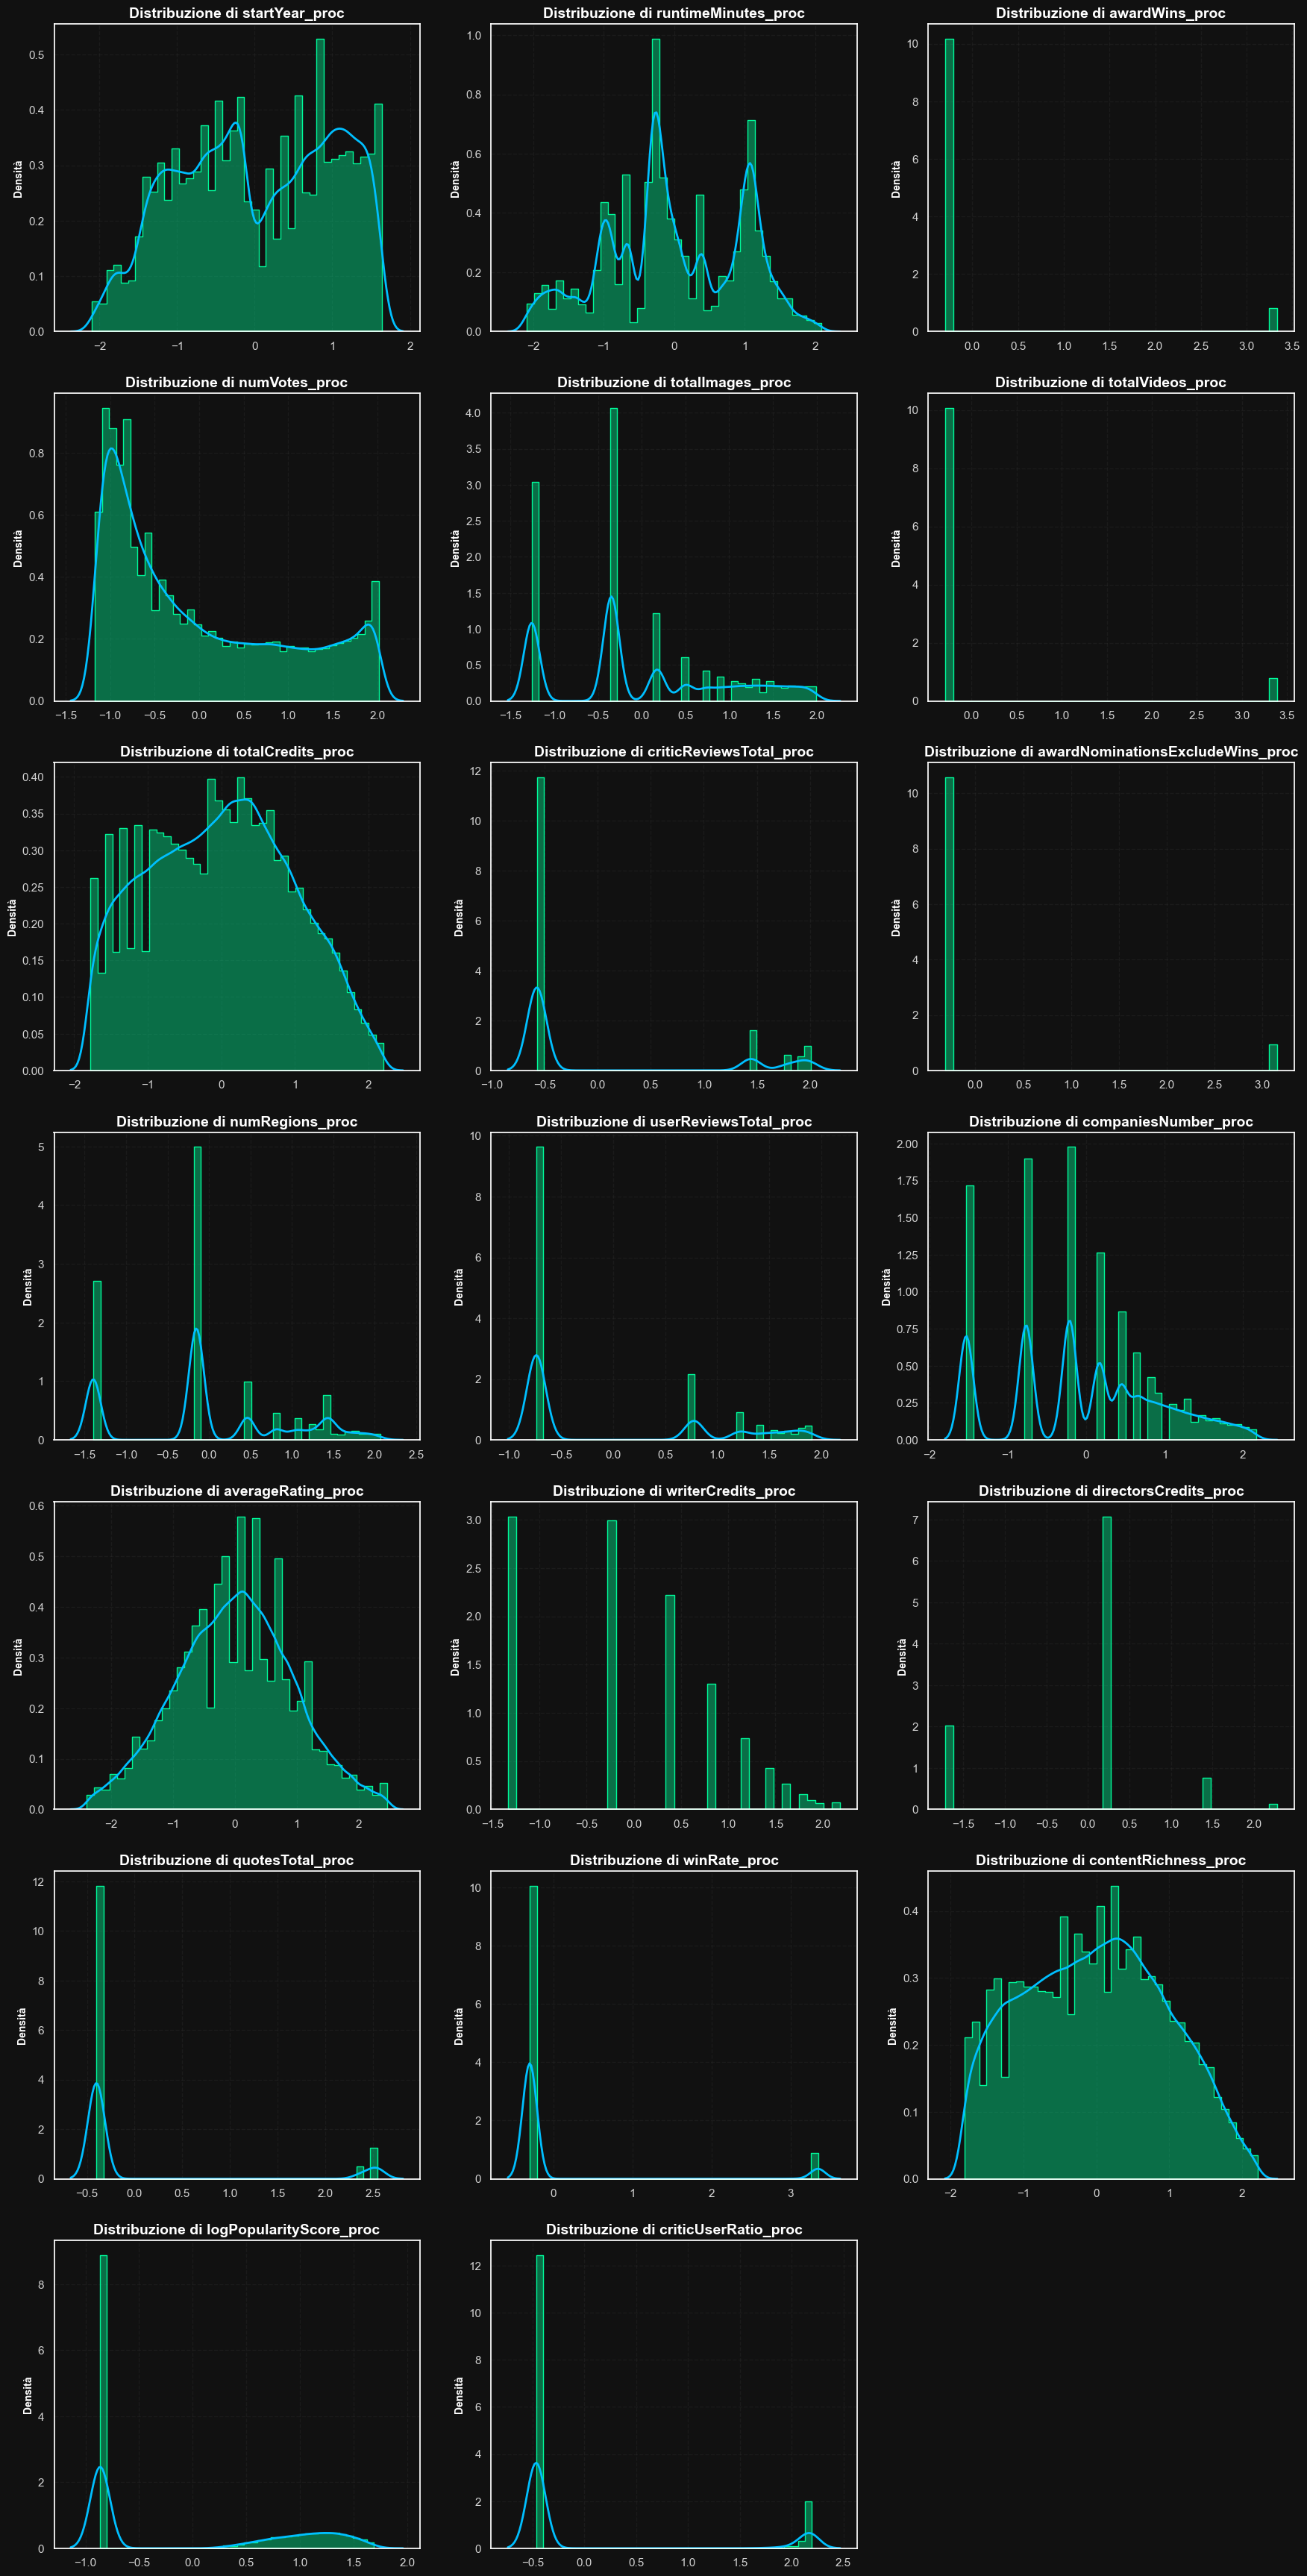

In [35]:
# %% md
#### Dashboard delle Distribuzioni delle Variabili Numeriche Trasformate con scaling dinamico
# %%
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math

# Selezione delle Colonne Numeriche
transformed_cols = [col for col in data.columns if col.endswith('_proc')]

# --- 2. Preparazione della Griglia di Plot ---
# Definiamo il layout della griglia: 3 colonne
ncols = 3
# Calcoliamo il numero di righe necessarie per contenere tutti i grafici
nrows = math.ceil(len(numeric_cols) / ncols)

# Creiamo la figura e la griglia di assi
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))

# "Appiattiamo" l'array di assi per poterlo iterare facilmente con un singolo indice
axes = axes.flatten()

# --- 3. Plotting sulla Griglia ---
histogram_color = "#00FA9A"  # MediumSpringGreen
kde_color = "#00BFFF"        # Azzurro (DeepSkyBlue)

for i, col in enumerate(transformed_cols):
    ax = axes[i] # Seleziona l'asse corrente per questo grafico

    try:
        series = pd.to_numeric(data[col], errors='coerce').dropna()

        if series.empty:
            ax.set_title(f"Colonna '{col}' vuota", fontsize=12)
            ax.set_visible(False) # Nascondi l'asse se la colonna è vuota
            continue

        # Riduci gli outlier per una visualizzazione più chiara
        lower = series.quantile(0.01)
        upper = series.quantile(0.99)
        trimmed_series = series[(series >= lower) & (series <= upper)]

        # Disegna l'istogramma sull'asse corrente 'ax'
        sns.histplot(
            x=trimmed_series,
            bins=40,
            element="step",
            fill=True,
            alpha=0.4,
            color=histogram_color,
            kde=False,
            stat="density",
            ax=ax
        )

        # Aggiungi il KDE se la variabile è continua
        if trimmed_series.nunique() > 15:
            sns.kdeplot(
                x=trimmed_series,
                color=kde_color,
                linewidth=2,
                ax=ax
            )

        ax.set_title(f'Distribuzione di {col}', fontsize=14, fontweight='bold')
        ax.set_xlabel('') # Rimuoviamo l'etichetta x per un look più pulito
        ax.set_ylabel('Densità', fontsize=10)


    except Exception as e:
        ax.set_title(f"Errore in '{col}'", fontsize=12)
        print(f"Errore durante la visualizzazione della colonna '{col}': {e}")

# --- 4. Pulizia Finale della Griglia ---
# Nascondi gli assi extra che non sono stati utilizzati
for j in range(len(transformed_cols), len(axes)):
    axes[j].set_visible(False)

# Applica un layout compatto per evitare sovrapposizioni e mostra la figura finale
plt.tight_layout(pad=2.0)
plt.savefig(plots_dir + 'numerical_raw_distributions.png', dpi=300)
plt.show()

#### Fine Notebook, Salvataggio del dataset preparato

In [36]:
import pandas as pd
import os

# --- SALVATAGGIO DATASET FINALE ---

# Definiamo la directory e il nome del file
output_dir = 'Dataset/'
output_filename_csv = 'imdb_prepared.csv' # Alternativa

# Creiamo la directory se non esiste
os.makedirs(output_dir, exist_ok=True)
print(f"✅ Directory di output '{output_dir}' pronta.")

try:
    print(f"\nSalvataggio in formato CSV")
    data.to_csv(os.path.join(output_dir, output_filename_csv), index=False)
    print(f"✅ Dataset salvato con successo in: {os.path.join(output_dir, output_filename_csv)}")
except Exception as e:
    print(f"❌ Errore durante il salvataggio del file: {e}")
    exit(1)

✅ Directory di output 'Dataset/' pronta.

Salvataggio in formato CSV
✅ Dataset salvato con successo in: Dataset/imdb_prepared.csv
